In [1]:
import sys
!{sys.executable} -m pip install pandas numpy networkx pulp

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import pulp

print("--- ENVIRONMENT CHECK ---")
print(f"Pandas version:   {pd.__version__}")
print(f"NumPy version:    {np.__version__}")
print(f"NetworkX version: {nx.__version__}")
print(f"PuLP version:     {pulp.__version__}")
print("\nSuccess! All required optimization libraries are successfully loaded.")

--- ENVIRONMENT CHECK ---
Pandas version:   2.3.3
NumPy version:    2.3.3
NetworkX version: 3.6.1
PuLP version:     3.3.2

Success! All required optimization libraries are successfully loaded.


In [3]:
# 1. Load the dataset
# Replace 'flight_schedule.csv' with your actual file path
df = pd.read_csv(r"F:\Sushreeta MSc.DDS\2nd Sem\Analytics Project\3rd Round of Work\Copy_project_data\flight_schedule.csv")

# 2. Convert string timestamps to datetime objects so Python understands time
df['SCHEDULED_DEPARTURE_TIME'] = pd.to_datetime(df['SCHEDULED_DEPARTURE_TIME'])
df['SCHEDULED_ARRIVAL_TIME'] = pd.to_datetime(df['SCHEDULED_ARRIVAL_TIME'])

# 3. Sort chronologically by departure time
# This is critical to ensure our graph is a Directed Acyclic Graph (DAG)
df = df.sort_values(by='SCHEDULED_DEPARTURE_TIME').reset_index(drop=True)

# 4. Calculate the base Flight Time (FT) for each leg in minutes
df['FLIGHT_TIME_MINS'] = (df['SCHEDULED_ARRIVAL_TIME'] - df['SCHEDULED_DEPARTURE_TIME']).dt.total_seconds() / 60

# Inspect the first few rows to ensure it looks correct
print("Data pipeline test successful! Here are the first 5 flights:")
print(df[['LEG_ID', 'DEPARTURE_AIRPORT', 'ARRIVAL_AIRPORT', 'SCHEDULED_DEPARTURE_TIME', 'FLIGHT_TIME_MINS']].head())

Data pipeline test successful! Here are the first 5 flights:
       LEG_ID DEPARTURE_AIRPORT ARRIVAL_AIRPORT SCHEDULED_DEPARTURE_TIME  \
0  3504619488               RAK             DUS      2025-04-27 02:10:00   
1  3504618802               TUN             CGN      2025-04-27 02:10:00   
2  3504619328               EVN             BER      2025-04-27 02:15:00   
3  3504619194               HAJ             PMI      2025-04-27 03:15:00   
4  3504619177               NUE             PMI      2025-04-27 03:40:00   

   FLIGHT_TIME_MINS  
0             235.0  
1             150.0  
2             265.0  
3             150.0  
4             130.0  


In [4]:
def load_and_preprocess_flights(file_path):
    """
    Loads flight schedules, converts timestamps to absolute minutes, 
    and sorts the dataset chronologically.
    """
    # 1. Load the csv file
    df = pd.read_csv(file_path)
    
    # 2. Parse string objects into pandas datetime objects
    df['SCHEDULED_DEPARTURE_TIME'] = pd.to_datetime(df['SCHEDULED_DEPARTURE_TIME'])
    df['SCHEDULED_ARRIVAL_TIME'] = pd.to_datetime(df['SCHEDULED_ARRIVAL_TIME'])
    
    # 3. Sort chronologically by departure time
    # This guarantees that our network flows forward in time (DAG)
    df = df.sort_values(by='SCHEDULED_DEPARTURE_TIME').reset_index(drop=True)
    
    # 4. Establish a global timeline baseline reference point (Day 1 at 00:00)
    baseline_date = df['SCHEDULED_DEPARTURE_TIME'].min().normalize()
    
    # 5. Map timestamps to absolute minutes from baseline
    df['DEP_MINUTES'] = (df['SCHEDULED_DEPARTURE_TIME'] - baseline_date).dt.total_seconds() / 60
    df['ARR_MINUTES'] = (df['SCHEDULED_ARRIVAL_TIME'] - baseline_date).dt.total_seconds() / 60
    
    # 6. Pre-calculate block flight time duration per leg
    df['FLIGHT_DURATION_MINS'] = df['ARR_MINUTES'] - df['DEP_MINUTES']
    
    return df, baseline_date

# Define operational parameters in minutes
MCT = 45          # Minimum Connection Time: 45 minutes
MIN_REST = 720    # Minimum Rest Period between duties: 12 hours (12 * 60)
CHECK_IN = 60     # Duty begins 60 minutes before first departure
CHECK_OUT = 30    # Duty ends 30 minutes after last arrival

print("Data processing functions defined successfully!")

Data processing functions defined successfully!


In [5]:
flights_df, timeline_start = load_and_preprocess_flights(r"F:\Sushreeta MSc.DDS\2nd Sem\Analytics Project\3rd Round of Work\Copy_project_data\flight_schedule.csv")
print(flights_df[['LEG_ID', 'DEPARTURE_AIRPORT', 'DEP_MINUTES', 'ARR_MINUTES', 'FLIGHT_DURATION_MINS']].head())

       LEG_ID DEPARTURE_AIRPORT  DEP_MINUTES  ARR_MINUTES  \
0  3504619488               RAK        130.0        365.0   
1  3504618802               TUN        130.0        280.0   
2  3504619328               EVN        135.0        400.0   
3  3504619194               HAJ        195.0        345.0   
4  3504619177               NUE        220.0        350.0   

   FLIGHT_DURATION_MINS  
0                 235.0  
1                 150.0  
2                 265.0  
3                 150.0  
4                 130.0  


In [6]:
flights_df.head()

,LEG_ID,DEPARTURE_AIRPORT,ARRIVAL_AIRPORT,SCHEDULED_DEPARTURE_TIME,SCHEDULED_ARRIVAL_TIME,AIRCRAFT_TYPE,DEP_MINUTES,ARR_MINUTES,FLIGHT_DURATION_MINS
0,3504619488,RAK,DUS,2025-04-27 02:10:00,2025-04-27 06:05:00,320,130.0,365.0,235.0
1,3504618802,TUN,CGN,2025-04-27 02:10:00,2025-04-27 04:40:00,737,130.0,280.0,150.0
2,3504619328,EVN,BER,2025-04-27 02:15:00,2025-04-27 06:40:00,320,135.0,400.0,265.0
3,3504619194,HAJ,PMI,2025-04-27 03:15:00,2025-04-27 05:45:00,320,195.0,345.0,150.0
4,3504619177,NUE,PMI,2025-04-27 03:40:00,2025-04-27 05:50:00,320,220.0,350.0,130.0


In [7]:

# 1. Convert the scheduled departure string into a true datetime object
flights_df['SCHEDULED_DEPARTURE_TIME'] = pd.to_datetime(flights_df['SCHEDULED_DEPARTURE_TIME'])

# 2. Extract just the date part (as a datetime object) for clean type-safe filtering
# Note: Using .dt.normalize() keeps it as a datetime type instead of casting to a date object,
# which allows direct, error-free comparisons with date strings!
flights_df['FLIGHT_DATE'] = flights_df['SCHEDULED_DEPARTURE_TIME'].dt.normalize()

# 3. Define the first week of the schedule (Match the year to your data, e.g., 2025 or 2026)
start_date = '2025-04-27'
end_date = '2025-05-03'

# 4. Slice the DataFrame cleanly
weekly_flights = flights_df[(flights_df['FLIGHT_DATE'] >= start_date) & 
                            (flights_df['FLIGHT_DATE'] <= end_date)].copy()

print(f"--- WEEK 1 SLICE COMPLETE ---")
print(f"Total flights found for Week 1: {len(weekly_flights)}")

--- WEEK 1 SLICE COMPLETE ---
Total flights found for Week 1: 3321


In [8]:

# Load your ground transport CSV file
gt_df = pd.read_csv(r"F:\Sushreeta MSc.DDS\2nd Sem\Analytics Project\3rd Round of Work\Copy_project_data\ground_transportation_times.csv")

# Convert to a fast lookup map: (Origin, Destination) -> duration_in_minutes
# Notice the '* 60' to convert decimal hours (e.g., 2.75) into minutes (165.0)
ground_transit_map = {
    (row['Dep Ap'].strip(), row['Arr Ap'].strip()): row['avg_duration'] * 60
    for _, row in gt_df.iterrows()
}

In [9]:
df_test = pd.read_csv(r"F:\Sushreeta MSc.DDS\2nd Sem\Analytics Project\3rd Round of Work\Copy_project_data\fdt_limits.csv")
print("--- CSV COLUMNS ---")
print(df_test.columns.tolist())
print("\n--- FIRST 2 ROWS ---")
print(df_test.head(2))

--- CSV COLUMNS ---
['flight_duty_time_start_time', 'flight_duty_time_end_time', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10']

--- FIRST 2 ROWS ---
  flight_duty_time_start_time flight_duty_time_end_time     1     2     3  \
0                    00:00:00                  04:59:00  11.0  11.0  10.5   
1                    05:00:00                  05:14:00  12.0  12.0  11.5   

      4     5     6    7    8    9   10  
0  10.0   9.5   9.0  9.0  9.0  9.0  9.0  
1  11.0  10.5  10.0  9.5  9.0  9.0  9.0  


In [10]:
def load_easa_limits(csv_path=r"F:\Sushreeta MSc.DDS\2nd Sem\Analytics Project\3rd Round of Work\Copy_project_data\fdt_limits.csv"):
    """
    Parses fdt_limits.csv using its exact structure:
    Rows are time windows, columns '1' through '10' are sectors containing limit hours.
    """
    df = pd.read_csv(csv_path)
    parsed_limits = []
    
    # Identify the sector columns dynamically (columns that are purely digits)
    sector_columns = [col for col in df.columns if col.isdigit()]
    
    for _, row in df.iterrows():
        # 1. Extract and convert start/end clock times to decimal hours
        start_str = str(row['flight_duty_time_start_time']).strip()
        end_str = str(row['flight_duty_time_end_time']).strip()
        
        start_h = pd.to_timedelta(start_str).total_seconds() / 3600.0
        end_h = pd.to_timedelta(end_str).total_seconds() / 3600.0
        
        # 2. Map each sector column to its minute value (hours * 60)
        sector_map = {}
        for col in sector_columns:
            num_sectors = int(col)
            # Convert float hours from CSV (e.g., 11.5) into total minutes (e.g., 690)
            max_fdt_minutes = int(float(row[col]) * 60)
            sector_map[num_sectors] = max_fdt_minutes
            
        parsed_limits.append(((start_h, end_h), sector_map))
        
    print(f"Successfully mapped {len(parsed_limits)} EASA time windows directly from fdt_limits.csv!")
    return parsed_limits

# Initialize the EASA rule parser globally using your file
EASA_FDT_LIMITS = load_easa_limits(r"F:\Sushreeta MSc.DDS\2nd Sem\Analytics Project\3rd Round of Work\Copy_project_data\fdt_limits.csv")

Successfully mapped 14 EASA time windows directly from fdt_limits.csv!


In [11]:
def get_max_fdt(check_in_minutes):
    """
    Looks up the dynamic EASA FDT limit based on the absolute minute of check-in.
    """
    minute_of_day = check_in_minutes % 1440
    hour_of_day = minute_of_day / 60.0
    
    for (start_h, end_h), sector_limits in EASA_FDT_LIMITS:
        # Handle night/dawn wrap-around windows if they cross midnight (e.g., 22:00 to 04:00)
        if start_h > end_h: 
            if hour_of_day >= start_h or hour_of_day <= end_h:
                return sector_limits
        else:
            if start_h <= hour_of_day <= end_h:
                return sector_limits
                
    # Safe default fallback matrix if no window catches it
    return {1: 720, 2: 720, 3: 690, 4: 660, 5: 630, 6: 600}

In [12]:
import pandas as pd

def generate_feasible_duties_with_transit(flights_df, ground_map, MCT=45):
    """
    Generates legal single-day duties accounting for ground transportation.
    Unifies the structural path search with the complete financial costing model,
    capturing flight hours, idle time inefficiencies, hotels, and transit penalties.
    
    CRITICAL FIXES:
    1. Changed chronological 'break' to 'continue' to preserve long-haul outstation options.
    2. Added an Emergency Recovery Overlay to capture isolated long-haul flights as 1-sector lines.
    3. Added Start-of-Day and End-of-Day ground transit positioning handlers to capture duties
       that begin or end with surface connections between neighboring bases.
    """
    feasible_duties = []
    num_flights = len(flights_df)
    flights = flights_df.to_dict(orient='records')
    
    # 1. Fast lookups for routing and flight durations
    flight_routing_map = {
        row['LEG_ID']: (row['DEPARTURE_AIRPORT'], row['ARRIVAL_AIRPORT'])
        for _, row in flights_df.iterrows()
    }
    flight_durations = {
        row['LEG_ID']: row['FLIGHT_DURATION_MINS'] 
        for _, row in flights_df.iterrows()
    }
    
    def dfs_extend_duty(current_path, last_idx):
        first_flight = current_path[0]
        last_flight = current_path[-1]
        
        # Base operational windows (before adding external ground transits)
        base_check_in = first_flight['DEP_MINUTES'] - 70   
        base_check_out = last_flight['ARR_MINUTES'] + 30   
        base_fdt = last_flight['ARR_MINUTES'] - base_check_in   
        num_sectors = len(current_path)
        
        # Pull the EASA max limits based on check-in hour
        sector_limits = get_max_fdt(base_check_in)
        lookup_sector = num_sectors if num_sectors in sector_limits else max(sector_limits.keys())
        max_allowed_fdt = sector_limits.get(lookup_sector, 600) 
        
        if base_fdt > max_allowed_fdt:
            return 
            
        has_valid_extensions = False
        
        if num_sectors < 5:  
            for next_idx in range(last_idx + 1, num_flights):
                next_flight = flights[next_idx]
                time_gap = next_flight['DEP_MINUTES'] - last_flight['ARR_MINUTES']
                
                if time_gap > 240 or time_gap < 0:
                    continue
                
                arr_ap = last_flight['ARRIVAL_AIRPORT']
                dep_ap = next_flight['DEPARTURE_AIRPORT']
                
                # Scenario A: Standard Mid-Duty Connection
                if arr_ap == dep_ap:
                    if MCT <= time_gap <= 240: 
                        has_valid_extensions = True
                        dfs_extend_duty(current_path + [next_flight], next_idx)
                        
                # Scenario B: Ground Surface Mid-Duty Connection
                elif (arr_ap, dep_ap) in ground_map:
                    transit_time = ground_map[(arr_ap, dep_ap)]
                    required_window = transit_time + MCT
                    if required_window <= time_gap <= 240:
                        has_valid_extensions = True
                        dfs_extend_duty(current_path + [next_flight], next_idx)

        # --- BALANCED AGGREGATION & PRUNING FILTER ---
        possible_home_bases = ['FRA', 'MUC', 'DUS', 'STR', 'HAM', 'CGN', 'BER', 'NUE', 'HAJ']
        is_at_base_hub = last_flight['ARRIVAL_AIRPORT'] in possible_home_bases
        if not has_valid_extensions or is_at_base_hub:
            leg_ids = [f['LEG_ID'] for f in current_path]
            
            # --- 2. EXTRACT GROUND TRANSPORTATION STRATEGIES (START / END) ---
            actual_origin = first_flight['DEPARTURE_AIRPORT']
            actual_destination = last_flight['ARRIVAL_AIRPORT']
            
            start_transit_minutes = 0.0
            start_transit_cost = 0.0
            start_itinerary_prefix = ""

            
            
            # 🌟 Evaluate Start-of-Day Ground Transit
            # If duty doesn't start at a core base, can we transit from a nearby one?
            if actual_origin not in possible_home_bases:
                for base in possible_home_bases:
                    if (base, actual_origin) in ground_map:
                        start_transit_minutes = ground_map[(base, actual_origin)]
                        start_transit_cost = 50.0 + (start_transit_minutes * 0.50)
                        start_itinerary_prefix = f"{base}🚌 ➔ "
                        actual_origin = base  # Duty now legally begins at this base
                        break

            end_transit_minutes = 0.0
            end_transit_cost = 0.0
            end_itinerary_suffix = ""

            # 🌟 Evaluate End-of-Day Ground Transit
            # If duty doesn't end at a core base, can we transit to a nearby one to conclude?
            if actual_destination not in possible_home_bases:
                for base in possible_home_bases:
                    if (actual_destination, base) in ground_map:
                        end_transit_minutes = ground_map[(actual_destination, base)]
                        end_transit_cost = 50.0 + (end_transit_minutes * 0.50)
                        end_itinerary_suffix = f" ➔ 🚌{base}"
                        actual_destination = base  # Duty now legally finishes back at this base
                        break

            # --- 3. RECALIBRATE LEGAL COMPLIANCE & WINDOWS ---
            # Adjust timestamps to encompass external ground transits
            final_check_in = base_check_in - start_transit_minutes
            final_check_out = base_check_out + end_transit_minutes
            total_duty_time = final_check_out - final_check_in
            
            # Flight Duty Time (FDT) expands to account for morning positioning travel
            final_fdt_duration = base_fdt + start_transit_minutes + end_transit_minutes
            
            # Re-verify absolute EASA legal safety caps after positioning modifications
            if final_fdt_duration > max_allowed_fdt:
                return

            # --- 4. ADVANCED FINANCIAL ENGINE ---
            total_flight_time = sum(flight_durations[leg_id] for leg_id in leg_ids)
            
            flying_cost = total_flight_time * 1.00
            inefficiency_cost = (total_duty_time - total_flight_time) * 0.50
            
            # Outstation Hotel Cost Check (Based on updated true origin/destination attributes)
            layover_cost = 150.0 if actual_origin != actual_destination else 0.0
            
            # Process Mid-Duty Ground Transport strings & financial weights
            mid_ground_transit_cost = 0.0
            mid_ground_minutes = 0.0
            itinerary_airports = [flight_routing_map[leg_ids[0]][0]]
            
            for k in range(len(current_path)):
                leg_id = leg_ids[k]
                dep_ap, arr_ap = flight_routing_map[leg_id]
                
                if k > 0 and itinerary_airports[-1] != dep_ap:
                    prev_arr = itinerary_airports[-1]
                    if (prev_arr, dep_ap) in ground_map:
                        transit_mins = ground_map[(prev_arr, dep_ap)]
                        mid_ground_minutes += transit_mins
                        mid_ground_transit_cost += 50.0 + (transit_mins * 0.50)
                        itinerary_airports.append(f"({prev_arr}🚌{dep_ap})")
                
                itinerary_airports.append(arr_ap)
            
            # Combine all travel segments into a unified itinerary tracking string
            duty_itinerary = start_itinerary_prefix + " ➔ ".join(itinerary_airports) + end_itinerary_suffix
            
            total_all_ground_transit_cost = start_transit_cost + mid_ground_transit_cost + end_transit_cost
            total_all_ground_minutes = start_transit_minutes + mid_ground_minutes + end_transit_minutes
            
            final_calculated_cost = flying_cost + inefficiency_cost + layover_cost + total_all_ground_transit_cost
            
            duty_info = {
                'flight_legs': leg_ids,
                'itinerary': duty_itinerary,  
                'origin_airport': actual_origin,
                'destination_airport': actual_destination,
                'start_time': final_check_in,
                'end_time': final_check_out,
                'fdt_duration': final_fdt_duration,
                'sectors': num_sectors,
                'ground_transit_mins': round(total_all_ground_minutes, 1), 
                'duty_cost': round(final_calculated_cost, 2)
            }
            feasible_duties.append(duty_info)

    # Execute recursive search for all core operational flights
    for i in range(num_flights):
        dfs_extend_duty([flights[i]], i)
        
    # --- 5. EMERGENCY RECOVERY OVERLAY ---
    legs_with_duties = set()
    for duty in feasible_duties:
        for leg in duty['flight_legs']:
            legs_with_duties.add(leg)
            
    print(f"Heuristic generated {len(feasible_duties)} base duties. Checking for gaps...")
    
    recovered_count = 0
    for f in flights:
        if f['LEG_ID'] not in legs_with_duties:
            check_in = f['DEP_MINUTES'] - 70
            check_out = f['ARR_MINUTES'] + 30
            fdt = f['ARR_MINUTES'] - check_in
            
            flying_cost = f['FLIGHT_DURATION_MINS'] * 1.00
            inefficiency_cost = (check_out - check_in - f['FLIGHT_DURATION_MINS']) * 0.50
            layover_cost = 150.0  
            
            recovery_duty = {
                'flight_legs': [f['LEG_ID']],
                'itinerary': f"{f['DEPARTURE_AIRPORT']} ➔ {f['ARRIVAL_AIRPORT']} (Layover Line)",
                'origin_airport': f['DEPARTURE_AIRPORT'],
                'destination_airport': f['ARRIVAL_AIRPORT'],
                'start_time': check_in,
                'end_time': check_out,
                'fdt_duration': fdt,
                'sectors': 1,
                'ground_transit_mins': 0.0,
                'duty_cost': round(flying_cost + inefficiency_cost + layover_cost, 2)
            }
            feasible_duties.append(recovery_duty)
            legs_with_duties.add(f['LEG_ID'])
            recovered_count += 1

    if recovered_count > 0:
        print(f"🛡️ Safety Net Triggered: Successfully recovered {recovered_count} long-haul gaps into layover duties.")
        
    return pd.DataFrame(feasible_duties)

In [13]:
print(ground_transit_map)

{('BCN', 'PGF'): 165.0, ('BER', 'DUS'): 231.6, ('BER', 'HAJ'): 233.4, ('BER', 'HAM'): 208.20000000000002, ('BER', 'NUE'): 328.8, ('BER', 'QBS'): 19.8, ('BER', 'QMU'): 277.2, ('BER', 'QPA'): 292.2, ('BER', 'STR'): 97.2, ('BER', 'ZMB'): 159.0, ('CGN', 'DTM'): 96.60000000000001, ('CGN', 'DUS'): 79.80000000000001, ('CGN', 'FRA'): 72.6, ('CGN', 'HAM'): 306.0, ('CGN', 'MUC'): 92.4, ('CGN', 'NUE'): 270.0, ('CGN', 'PAD'): 145.2, ('CGN', 'QKL'): 30.0, ('CGN', 'QPA'): 202.79999999999998, ('CGN', 'STR'): 226.2, ('CGN', 'VLB'): 79.80000000000001, ('CGN', 'ZWS'): 177.0, ('DTM', 'DUS'): 80.4, ('DUS', 'FMO'): 118.8, ('DUS', 'FRA'): 98.39999999999999, ('DUS', 'HAJ'): 165.6, ('DUS', 'HAM'): 226.79999999999998, ('DUS', 'NUE'): 198.6, ('DUS', 'QDU'): 30.0, ('DUS', 'QMU'): 88.8, ('DUS', 'STR'): 262.2, ('DUS', 'VLB'): 50.4, ('DUS', 'ZMB'): 220.8, ('DUS', 'ZWS'): 208.8, ('DWC', 'DXB'): 60.0, ('FMO', 'QMU'): 30.0, ('FMO', 'VLB'): 115.19999999999999, ('FRA', 'NUE'): 166.2, ('FRA', 'QES'): 199.8, ('FRA', 'QKL'

In [14]:
# 1. Generate the legal single-day duties using your processed flights dataframe
weekly_duties = generate_feasible_duties_with_transit(weekly_flights, ground_transit_map, MCT=45)

# 2. Print the verification metrics
print("\n--- LAYER 1: DUTY GENERATION COMPLETE ---")
print(f"Total valid daily duties discovered: {len(weekly_duties)}")

if len(weekly_duties) > 0:
    print("\nSample Generated Duties Layout:")
    print(weekly_duties[['flight_legs', 'origin_airport', 'destination_airport', 'fdt_duration', 'sectors']].head())

Heuristic generated 38724 base duties. Checking for gaps...
🛡️ Safety Net Triggered: Successfully recovered 8 long-haul gaps into layover duties.

--- LAYER 1: DUTY GENERATION COMPLETE ---
Total valid daily duties discovered: 38732

Sample Generated Duties Layout:
                flight_legs origin_airport destination_airport  fdt_duration  \
0  [3504619488, 3504619464]            RAK                 OTP         500.0   
1  [3504619488, 3504619358]            RAK                 NCE         470.0   
2  [3504619488, 3504619366]            RAK                 LHR         445.0   
3  [3504619488, 3504619476]            RAK                 FLR         475.0   
4  [3504619488, 3504619450]            RAK                 KRK         480.0   

   sectors  
0        2  
1        2  
2        2  
3        2  
4        2  


In [15]:
gt_duties = weekly_duties[weekly_duties['ground_transit_mins'] > 0]
print(gt_duties[['flight_legs', 'origin_airport', 'destination_airport', 'ground_transit_mins', 'duty_cost']].head())

                 flight_legs origin_airport destination_airport  \
9   [3504618802, 3504619448]            TUN                 MLA   
10  [3504618802, 3504619464]            TUN                 OTP   
11  [3504618802, 3504619358]            TUN                 NCE   
12  [3504618802, 3504619366]            TUN                 LHR   
13  [3504618802, 3504619476]            TUN                 FLR   

    ground_transit_mins  duty_cost  
9                  79.8      672.4  
10                 79.8      654.9  
11                 79.8      619.9  
12                 79.8      594.9  
13                 79.8      619.9  


In [16]:
weekly_duties.to_csv('single_day_duties.csv', index=False, encoding='utf-8-sig')

In [17]:
weekly_duties.head()

,flight_legs,itinerary,origin_airport,destination_airport,start_time,end_time,fdt_duration,sectors,ground_transit_mins,duty_cost
0,"[3504619488, 3504619464]",RAK ➔ DUS ➔ OTP,RAK,OTP,60.0,590.0,500.0,2,0.0,607.5
1,"[3504619488, 3504619358]",RAK ➔ DUS ➔ NCE,RAK,NCE,60.0,560.0,470.0,2,0.0,572.5
2,"[3504619488, 3504619366]",RAK ➔ DUS ➔ LHR,RAK,LHR,60.0,535.0,445.0,2,0.0,547.5
3,"[3504619488, 3504619476]",RAK ➔ DUS ➔ FLR,RAK,FLR,60.0,565.0,475.0,2,0.0,572.5
4,"[3504619488, 3504619450]",RAK ➔ DUS ➔ KRK,RAK,KRK,60.0,570.0,480.0,2,0.0,575.0


In [18]:
# 1. Define your target week's core boundaries (same as your optimization layer)
start_date = '2025-04-27'
end_date = '2025-05-03'
core_start_dt = pd.to_datetime(f"{start_date} 00:00:00")
core_end_dt = pd.to_datetime(f"{end_date} 23:59:59")

# 2. Extract the absolute ground-truth list of legs that SHOULD be covered
core_flights = flights_df[(flights_df['SCHEDULED_DEPARTURE_TIME'] >= core_start_dt) & 
                          (flights_df['SCHEDULED_DEPARTURE_TIME'] <= core_end_dt)]
scheduled_legs = set(core_flights['LEG_ID'].unique())

# 3. Flatten and extract all flight legs that are ACTUALLY packed inside your duties
# (Explodes the lists of legs inside the 'flight_legs' column into a single flat set)
covered_legs_in_duties = set()
for legs_list in weekly_duties['flight_legs']:
    if isinstance(legs_list, list):
        # Only track legs that actually belong to our core target week
        for leg in legs_list:
            if leg in scheduled_legs:
                covered_legs_in_duties.add(leg)

# 4. Perform Set Difference Math to find gaps
missing_legs = scheduled_legs - covered_legs_in_duties

# 5. Print out the formal audit results
print("============= WEEKLY DUTY COVERAGE AUDIT =============")
print(f"Total Unique Legs Scheduled in Raw Data : {len(scheduled_legs)}")
print(f"Total Unique Legs Covered in Duty Pool  : {len(covered_legs_in_duties)}")

if len(missing_legs) == 0:
    print("🎉 SUCCESS: 100% of the week's flight legs are successfully represented in the single-day duties!")
else:
    print(f"⚠️ CRITICAL ALERT: {len(missing_legs)} flight legs are completely UNCOVERED by your daily duties!")
    print("❌ These legs will fail immediately in the Master Problem and force expensive €500k artificial stubs.")
    print("\nSample list of missing Leg IDs:")
    print(list(missing_legs)[:10])
    
    # Optional: Inspect what these missing flights look like to find out why they failed
    print("\nInspecting missing flights sample metadata:")
    display(core_flights[core_flights['LEG_ID'].isin(list(missing_legs)[:5])][
        ['LEG_ID', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE_TIME']
    ])

============= WEEKLY DUTY COVERAGE AUDIT =============
Total Unique Legs Scheduled in Raw Data : 3321
Total Unique Legs Covered in Duty Pool  : 3321
🎉 SUCCESS: 100% of the week's flight legs are successfully represented in the single-day duties!


In [19]:
import numpy as np
import pandas as pd
import networkx as nx

def build_pairing_graph_robust(duties_df, MIN_REST=720, MAX_LAYOVER=2160, max_nodes=100000, 
                               max_successors_per_node=20):
    """
    Fully robust network graph builder. Automatically injects:
    1. Outbound Evacuation Deadheads (Rescues crews stuck at outstations)
    2. Inbound Positioning Deadheads (Positions crews to fly orphaned outstation departures)
    """
    if len(duties_df) > max_nodes:
        print(f"Sampling the top {max_nodes} structurally diverse duties...")
        working_df = duties_df.sort_values(by=['duty_cost', 'start_time']).head(max_nodes).copy()
    else:
        working_df = duties_df.copy()

    G = nx.DiGraph()
    unique_bases = {'FRA', 'MUC', 'DUS', 'STR', 'HAM', 'CGN', 'BER', 'NUE', 'HAJ'}
    
    print("Vectorizing nodes into memory network...")
    for idx, row in working_df.iterrows():
        G.add_node(idx,
                   origin=row['origin_airport'],
                   destination=row['destination_airport'],
                   start=row['start_time'],
                   end=row['end_time'],
                   cost=row['duty_cost'],
                   legs=row['flight_legs'])
        
    print("Executing matrix cross-join connection tracking...")
    node_ids = working_df.index.to_numpy()
    origins = working_df['origin_airport'].to_numpy()
    destinations = working_df['destination_airport'].to_numpy()
    starts = working_df['start_time'].to_numpy()
    ends = working_df['end_time'].to_numpy()
    
    edge_list = []
    unique_airports = working_df['origin_airport'].unique()
    
    nodes_with_successors = set()
    nodes_with_predecessors = set()
    
    for airport in unique_airports:
        idx_A = np.where(destinations == airport)[0]  # Arriving duties
        idx_B = np.where(origins == airport)[0]       # Departing duties
        
        if len(idx_A) == 0 or len(idx_B) == 0:
            continue
            
        layovers = starts[idx_B][None, :] - ends[idx_A][:, None]
        valid_pairs = (layovers >= MIN_REST) & (layovers <= MAX_LAYOVER)
        row_indices, col_indices = np.where(valid_pairs)
        
        local_connections = {r: [] for r in np.unique(row_indices)}
        for r, c in zip(row_indices, col_indices):
            local_connections[r].append((c, layovers[r, c]))
            
        for r, options in local_connections.items():
            global_idx_A = node_ids[idx_A[r]]
            sorted_options = sorted(options, key=lambda x: x[1])
            
            for c, layover_time in sorted_options[:max_successors_per_node]:
                global_idx_B = node_ids[idx_B[c]]
                edge_list.append((global_idx_A, global_idx_B, {'layover_time': layover_time, 'type': 'organic'}))
                nodes_with_successors.add(global_idx_A)
                nodes_with_predecessors.add(global_idx_B)

    print(f"Writing {len(edge_list)} organic edges into the graph...")
    G.add_edges_from(edge_list)
    
    # -------------------------------------------------------------
    # BATCH EXTRACTIONS FOR VIRTUAL RECOVERY PIPELINES
    # -------------------------------------------------------------
    print("Injecting structural positioning and evacuation networks...")
    new_virtual_nodes = {}
    new_virtual_edges = []
    virtual_id_counter = -1
    
    # Map out real duties by day and location to hook up virtual routes quickly
    base_starts_by_day = {}
    base_ends_by_day = {}
    for n, attr in G.nodes(data=True):
        day = int(attr['start'] // 1440) + 1
        if attr['origin'] in unique_bases:
            base_starts_by_day.setdefault((day, attr['origin']), []).append(n)
        if attr['destination'] in unique_bases:
            base_ends_by_day.setdefault((day, attr['destination']), []).append(n)

    # Loop through the graph safely to evaluate stranded nodes
    for n, attr in list(G.nodes(data=True)):
        orig = attr['origin']
        dest = attr['destination']
        start_time = attr['start']
        end_time = attr['end']
        duty_day = int(start_time // 1440) + 1
        
        # 1. OUTBOUND EVACUATION (Rescues crews left stranded at an outstation)
        if dest not in unique_bases and n not in nodes_with_successors:
            next_day = duty_day + 1
            for hub in unique_bases:
                targets = base_starts_by_day.get((next_day, hub), []) + base_starts_by_day.get((next_day + 1, hub), [])
                if targets:
                    dh_start = end_time + int(MIN_REST)
                    dh_end = dh_start + 180
                    
                    vh_id = virtual_id_counter
                    virtual_id_counter -= 1
                    
                    new_virtual_nodes[vh_id] = {'origin': dest, 'destination': hub, 'start': dh_start, 'end': dh_end, 'cost': 400.0, 'legs': []}
                    new_virtual_edges.append((n, vh_id, {'layover_time': MIN_REST, 'type': 'evac_out'}))
                    for t in targets[:5]:
                        layover = G.nodes[t]['start'] - dh_end
                        if MIN_REST <= layover <= 2880:  # Relaxed hub-layover limit
                            new_virtual_edges.append((vh_id, t, {'layover_time': layover, 'type': 'evac_hub_connect'}))

        # 2. INBOUND POSITIONING (NEW: Positions crews to fly an orphaned outstation departure)
        if orig not in unique_bases and n not in nodes_with_predecessors:
            prev_day = duty_day - 1
            for hub in unique_bases:
                # Find real duties ending at a hub that can feed this crew member into a positioning deadhead
                feeders = base_ends_by_day.get((prev_day, hub), []) + base_ends_by_day.get((prev_day - 1, hub), [])
                
                # If it's Day 1, allow them to step right out of the hub airport terminal directly
                if duty_day == 1 or feeders:
                    dh_end = start_time - int(MIN_REST)
                    dh_start = dh_end - 180  # 3 hours back
                    
                    vh_id = virtual_id_counter
                    virtual_id_counter -= 1
                    
                    new_virtual_nodes[vh_id] = {'origin': hub, 'destination': orig, 'start': dh_start, 'end': dh_end, 'cost': 400.0, 'legs': []}
                    new_virtual_edges.append((vh_id, n, {'layover_time': MIN_REST, 'type': 'position_in'}))
                    
                    # Link previous-day hub flights to this positioning flight
                    for f in feeders[:5]:
                        layover = dh_start - G.nodes[f]['end']
                        if MIN_REST <= layover <= 2880:
                            new_virtual_edges.append((f, vh_id, {'layover_time': layover, 'type': 'position_feed'}))

    # Add staging details to graph cleanly
    print(f"Batch-injecting structural updates into network architecture...")
    for node_id, node_attrs in new_virtual_nodes.items():
        G.add_node(node_id, **node_attrs)
    G.add_edges_from(new_virtual_edges)

    print(f"Success! Graph Composition -> Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")
    return G

In [20]:
# 1. Rebuild the pairing network graph using our pruned logic
weekly_G = build_pairing_graph_robust(
    weekly_duties, 
    MIN_REST=720, 
    MAX_LAYOVER=2160,       # Capped at 36 hours max hotel stay
    max_nodes=100000, 
    max_successors_per_node=20  # Only links to the 20 best connecting flights
)



Vectorizing nodes into memory network...
Executing matrix cross-join connection tracking...
Writing 642317 organic edges into the graph...
Injecting structural positioning and evacuation networks...
Batch-injecting structural updates into network architecture...
Success! Graph Composition -> Nodes: 220013 | Edges: 874648


In [21]:
import networkx as nx

# 1. Extract the absolute ground-truth list of scheduled legs for your target week
core_start_dt = pd.to_datetime(f"{start_date} 00:00:00")
core_end_dt = pd.to_datetime(f"{end_date} 23:59:59")
core_flights = flights_df[(flights_df['SCHEDULED_DEPARTURE_TIME'] >= core_start_dt) & 
                          (flights_df['SCHEDULED_DEPARTURE_TIME'] <= core_end_dt)]
scheduled_legs = set(core_flights['LEG_ID'].unique())

# 2. Extract legs that are trapped inside the graph's active nodes (duties)
covered_legs_in_graph = set()
for node_id in weekly_G.nodes():
    node_legs = weekly_G.nodes[node_id].get('legs', [])
    if isinstance(node_legs, list):
        for leg in node_legs:
            if leg in scheduled_legs:
                covered_legs_in_graph.add(leg)

# 3. Calculate missing legs
missing_legs_in_graph = scheduled_legs - covered_legs_in_graph

print("============= GRAPH LEG COVERAGE AUDIT =============")
print(f"Total Unique Legs Scheduled in Raw Data : {len(scheduled_legs)}")
print(f"Total Unique Legs Preserved in Graph Nodes: {len(covered_legs_in_graph)}")

if len(missing_legs_in_graph) == 0:
    print("🎉 SUCCESS: All flight legs are represented inside the graph's nodes!")
else:
    print(f"⚠️ ALERT: {len(missing_legs_in_graph)} flight legs are completely missing from the graph.")
    print("This means the duties containing these legs were dropped during the graph's downsampling step.")

============= GRAPH LEG COVERAGE AUDIT =============
Total Unique Legs Scheduled in Raw Data : 3321
Total Unique Legs Preserved in Graph Nodes: 3321
🎉 SUCCESS: All flight legs are represented inside the graph's nodes!


In [22]:
import networkx as nx
import numpy as np

print("============= EXECUTING FAST NETWORK GRAPH AUDIT =============")

# -------------------------------------------------------------
# 1. PARSE GROUND TRUTH FROM THE GRAPH METADATA & DEFINE BASES
# -------------------------------------------------------------
# 🌟 FIX: Explicitly define the base hubs (matching your pricing engine updates)
unique_bases = {'FRA', 'MUC', 'DUS', 'STR', 'HAM', 'CGN', 'BER', 'NUE', 'HAJ'}

nodes_data = list(weekly_G.nodes(data=True))

# Extract all unique legs present anywhere in the graph nodes
all_legs_in_graph_nodes = set()
for n, attr in nodes_data:
    all_legs_in_graph_nodes.update(attr.get('legs', []))

start_nodes = [n for n, attr in nodes_data if attr.get('origin') in unique_bases and n >= 0]
is_end_node = {n: (attr.get('destination') in unique_bases) for n, attr in nodes_data}

# Dictionary to track exactly how many pairings terminate on each day
pairings_by_duration = {1: 0, 2: 0, 3: 0, 4: 0}
legs_covered_by_valid_pairings = set()

# -------------------------------------------------------------
# 2. COUNT 1-DAY STANDALONE PAIRINGS & RECOVER THEIR LEGS
# -------------------------------------------------------------
for n in start_nodes:
    # A standalone pairing must end at a base on its first structural duty block
    if is_end_node[n]:
        pairings_by_duration[1] += 1
        legs_covered_by_valid_pairings.update(weekly_G.nodes[n].get('legs', []))

print("✓ Processed 1-Day base-to-base standalone pairings.")

# -------------------------------------------------------------
# 3. ROBUST PATH PROPAGATION LAYER
# -------------------------------------------------------------
# To prevent the set-union blending bug, we trace valid paths using 
# a reachability tracking dictionary mapping: node -> set of valid start nodes
reachable_from_start = {n: set() for n in weekly_G.nodes()}
paths_to = {n: 0 for n in weekly_G.nodes()}

# Initialize Day 1
for n in start_nodes:
    paths_to[n] = 1
    reachable_from_start[n].add(n)

# We will collect nodes that successfully complete valid, legal pairings on each day layer
valid_nodes_by_day = {1: set(n for n in start_nodes if is_end_node[n]), 2: set(), 3: set(), 4: set()}

for step in range(1, 4):
    next_paths_to = {n: 0 for n in weekly_G.nodes()}
    next_reachable = {n: set() for n in weekly_G.nodes()}
    
    for current_node, current_path_count in paths_to.items():
        if current_path_count == 0:
            continue
            
        for successor in weekly_G.successors(current_node):
            next_paths_to[successor] += current_path_count
            next_reachable[successor].update(reachable_from_start[current_node])
            
    # Roll over values for the next step horizon
    paths_to = next_paths_to
    for n in weekly_G.nodes():
        if next_paths_to[n] > 0:
            reachable_from_start[n].update(next_reachable[n])
            
    day_label = step + 1
    for n, count in paths_to.items():
        if count > 0 and is_end_node[n]:
            pairings_by_duration[day_label] += count
            valid_nodes_by_day[day_label].add(n)
            
    print(f"✓ Processed structural pairings finishing on Day {day_label}.")

# -------------------------------------------------------------
# 4. BACKWARD REACHABILITY SWEEP TO RECOVER TRUE LEG COVERAGE
# -------------------------------------------------------------
# A leg is ONLY valid if it is part of a path that actually started at a base AND finished at a base
truly_valid_nodes = set()
for day in [1, 2, 3, 4]:
    truly_valid_nodes.update(valid_nodes_by_day[day])

# Backward BFS to catch all ancestor nodes that feed into the valid termination endpoints
queue = list(truly_valid_nodes)
visited_ancestors = set(queue)

# Create a reverse graph for rapid backward traversal
reverse_G = weekly_G.reverse(copy=False)

while queue:
    curr = queue.pop(0)
    # Only step backward if this node was reachable from a valid start node to begin with
    if len(reachable_from_start[curr]) > 0:
        for parent in reverse_G.successors(curr):
            if parent not in visited_ancestors and len(reachable_from_start[parent]) > 0:
                visited_ancestors.add(parent)
                queue.append(parent)

# Accumulate the flight legs strictly from nodes confirmed to be on a valid base-to-base pathway
for n in visited_ancestors:
    legs_covered_by_valid_pairings.update(weekly_G.nodes[n].get('legs', []))

# -------------------------------------------------------------
# 5. FINAL GENERATION & COVERAGE RESULTS REPORT
# -------------------------------------------------------------
total_pairings_count = sum(pairings_by_duration.values())

print("\n================== FINAL GRAPH AUDIT REPORT ==================")
print(f"Total Unique Multi-Day Pairings Generated : {total_pairings_count:,}")
print(f" └─ Completed on Day 1 (Standalone)     : {pairings_by_duration[1]:,}")
print(f" └─ Completed on Day 2                 : {pairings_by_duration[2]:,}")
print(f" └─ Completed on Day 3                 : {pairings_by_duration[3]:,}")
print(f" └─ Completed on Day 4                 : {pairings_by_duration[4]:,}")
print("-" * 62)
print(f"Total Unique Flight Legs Stored in Nodes  : {len(all_legs_in_graph_nodes)}")
print(f"Total Unique Legs Covered by VALID Paths  : {len(legs_covered_by_valid_pairings)}")

# Cross-reference to isolate unconnectable dead ends
orphaned_legs = all_legs_in_graph_nodes - legs_covered_by_valid_pairings

if len(orphaned_legs) == 0:
    print("\n🎉 PERFECT SCORE: 100% of the flight legs in the graph are reachable via a valid crew pairing!")
else:
    print(f"\n⚠️ STRUCTURAL ISSUE: {len(orphaned_legs)} legs exist in your nodes but CANNOT be used in a legal pairing.")
    print("These duties are 'trapped'—they either start at an outstation with no next-day flight out,")
    print("or their chain cannot reach a valid crew hub within the 4-day structural cap.")
    print(f"Sample stranded Leg IDs: {list(orphaned_legs)[:10]}")

============= EXECUTING FAST NETWORK GRAPH AUDIT =============
✓ Processed 1-Day base-to-base standalone pairings.
✓ Processed structural pairings finishing on Day 2.
✓ Processed structural pairings finishing on Day 3.
✓ Processed structural pairings finishing on Day 4.

================== FINAL GRAPH AUDIT REPORT ==================
Total Unique Multi-Day Pairings Generated : 43,778,770
 └─ Completed on Day 1 (Standalone)     : 10,768
 └─ Completed on Day 2                 : 181,892
 └─ Completed on Day 3                 : 2,800,005
 └─ Completed on Day 4                 : 40,786,105
--------------------------------------------------------------
Total Unique Flight Legs Stored in Nodes  : 3321
Total Unique Legs Covered by VALID Paths  : 3131

⚠️ STRUCTURAL ISSUE: 190 legs exist in your nodes but CANNOT be used in a legal pairing.
These duties are 'trapped'—they either start at an outstation with no next-day flight out,
or their chain cannot reach a valid crew hub within the 4-day struc

In [23]:
# Isolate a stranded leg to diagnose the network hole
stranded_id = 3505310723
sample_flight = flights_df[flights_df['LEG_ID'] == stranded_id].iloc[0]

print(f"--- Diagnostic for Stranded Leg {stranded_id} ---")
print(f"Route: {sample_flight['DEPARTURE_AIRPORT']} ➔ {sample_flight['ARRIVAL_AIRPORT']}")
print(f"Departure Time (Mins): {sample_flight['DEP_MINUTES']}")
print(f"Arrival Time (Mins): {sample_flight['ARR_MINUTES']}")

# Look for any flights that could logically follow this flight from that arrival airport
successors = flights_df[
    (flights_df['DEPARTURE_AIRPORT'] == sample_flight['ARRIVAL_AIRPORT']) & 
    (flights_df['DEP_MINUTES'] >= sample_flight['ARR_MINUTES'])
].head(5)

print("\nPossible next flights departing from that airport:")
print(successors[['LEG_ID', 'DEPARTURE_AIRPORT', 'ARRIVAL_AIRPORT', 'DEP_MINUTES']])

--- Diagnostic for Stranded Leg 3505310723 ---
Route: CGN ➔ BIA
Departure Time (Mins): 9450.0
Arrival Time (Mins): 9560.0

Possible next flights departing from that airport:
          LEG_ID DEPARTURE_AIRPORT ARRIVAL_AIRPORT  DEP_MINUTES
3171  3505310885               BIA             HAJ       9575.0
3184  3505310725               BIA             CGN       9600.0
5052  3505379327               BIA             BER      14990.0
5200  3505379407               BIA             DUS      15305.0
6669  3505434037               BIA             STR      19270.0


In [24]:
# 1. Identify the specific node IDs that are trapped
valid_legs_in_pairings = legs_covered_by_valid_pairings # From your fast audit run
trapped_nodes = []

for n, attr in weekly_G.nodes(data=True):
    # Only look at real duties (ignore virtual negative-ID deadheads)
    if n >= 0: 
        node_legs = attr.get('legs', [])
        # If any leg in this duty is part of the 395 trapped legs
        if any(leg in orphaned_legs for leg in node_legs):
            trapped_nodes.append(n)

# 2. Pull the raw data rows for these trapped duties to analyze them
trapped_duties_df = weekly_duties.loc[trapped_nodes].copy()

# Add helper columns for easy reading
trapped_duties_df['start_day'] = (trapped_duties_df['start_time'] // 1440) + 1

print("============= TRAPPED DUTY INFRASTRUCTURE ANALYSIS =============")
print(f"Total duties holding the 395 trapped legs: {len(trapped_duties_df)}")

print("\nBreakdown of Trapped Duties by STARTING AIRPORT:")
print(trapped_duties_df['origin_airport'].value_counts())

print("\nBreakdown of Trapped Duties by OPERATIONAL DAY OF THE WEEK:")
print(trapped_duties_df['start_day'].value_counts().sort_index())

print("\nSample of Trapped Duties:")
display(trapped_duties_df[['origin_airport', 'destination_airport', 'start_day', 'flight_legs']].head(10))

============= TRAPPED DUTY INFRASTRUCTURE ANALYSIS =============
Total duties holding the 395 trapped legs: 4122

Breakdown of Trapped Duties by STARTING AIRPORT:
origin_airport
LHR    344
ARN    320
BGY    171
SZG    149
NCE    140
      ... 
SPC      1
NUE      1
BIO      1
BLQ      1
DTM      1
Name: count, Length: 93, dtype: int64

Breakdown of Trapped Duties by OPERATIONAL DAY OF THE WEEK:
start_day
1.0    802
2.0    897
3.0    258
4.0    620
5.0    575
6.0    264
7.0    706
Name: count, dtype: int64

Sample of Trapped Duties:


,origin_airport,destination_airport,start_day,flight_legs
0,RAK,OTP,1.0,"[3504619488, 3504619464]"
1,RAK,NCE,1.0,"[3504619488, 3504619358]"
2,RAK,LHR,1.0,"[3504619488, 3504619366]"
3,RAK,FLR,1.0,"[3504619488, 3504619476]"
4,RAK,KRK,1.0,"[3504619488, 3504619450]"
5,RAK,PRN,1.0,"[3504619488, 3504619147]"
6,RAK,DBV,1.0,"[3504619488, 3504619491]"
7,RAK,DUS,1.0,[3504619488]
8,TUN,BER,1.0,"[3504618802, 3504618882, 3504619327]"
9,TUN,MLA,1.0,"[3504618802, 3504619448]"


# Optimization with gurobi rmp

In [25]:
# Convert your unique bases back to a set for fast lookup
unique_bases = {'FRA', 'MUC', 'DUS', 'STR', 'HAM', 'CGN', 'BER', 'NUE', 'HAJ'}

day1_standalone_pairings_list = []

print("Extracting organic Day 1 standalone pairings from duty library...")
# Loop through your single-day duties DataFrame
for idx, row in weekly_duties.iterrows():
    origin = row['origin_airport']
    destination = row['destination_airport']
    
    # Condition: It must start and end at the exact same valid crew hub base
    if origin in unique_bases and origin == destination:
        standalone_pairing = {
            'pairing_id': f"ORGANIC_ST_STND_{idx}",
            'covered_legs': row['flight_legs'],
            'cost': float(row['duty_cost']),
            'origin_base': origin,
            'duration_days': 1
        }
        day1_standalone_pairings_list.append(standalone_pairing)

print(f"✓ Found {len(day1_standalone_pairings_list)} standalone 1-day pairings.")

Extracting organic Day 1 standalone pairings from duty library...
✓ Found 2320 standalone 1-day pairings.


In [26]:
emergency_columns = []

print("Manufacturing emergency stub columns for trapped flights...")
# Iterate through the 395 stranded leg IDs found in your graph audit
for leg_id in orphaned_legs:
    stub_column = {
        'pairing_id': f"EMERGENCY_STUB_{leg_id}",
        'covered_legs': [leg_id],
        'cost': 500000.0,  # €500k penalty fee to force Gurobi to use it only as a last resort
        'origin_base': 'SYSTEM',
        'duration_days': 1
    }
    emergency_columns.append(stub_column)

print(f"✓ Manufactured {len(emergency_columns)} emergency stub columns.")

Manufacturing emergency stub columns for trapped flights...
✓ Manufactured 190 emergency stub columns.


In [27]:
# Create the initial pool to kick off your Restricted Master Problem
initial_pool = day1_standalone_pairings_list + emergency_columns
print(f"Total columns ready for initial Master Problem pool: {len(initial_pool):,}")

Total columns ready for initial Master Problem pool: 2,510


In [28]:
# Track every exact network path configuration we have sent to Gurobi across all iterations
generated_pairing_signatures = set()

def dfs_price(G, dual_values, max_columns_to_add=500, structural_day_cap=4):
    """
    Advanced Pricing Subproblem: Explores weekly_G using an optimized DFS.
    Resolves the stub explosion by standardizing German bases and ensuring chronological unique tracking.
    """
    global generated_pairing_signatures
    
    unique_bases = {'FRA', 'MUC', 'DUS', 'STR', 'HAM', 'CGN', 'BER', 'NUE', 'HAJ'}
    profitable_columns = []
    
    # Gather starting nodes that originate from a valid base
    start_nodes = [n for n, attr in G.nodes(data=True) if attr.get('origin') in unique_bases and n >= 0]
    column_counter = len(generated_pairing_signatures)

    def search(current_node, current_path, accumulated_legs, real_cost, reduced_cost, start_day):
        nonlocal column_counter
        
        # Globally enforce column limits
        if len(profitable_columns) >= max_columns_to_add:
            return

        node_attr = G.nodes[current_node]
        current_day = int(node_attr['end'] // 1440) + 1
        duration = current_day - start_day + 1

        # Hard constraint pruning: block schedules exceeding the day limit
        if duration > structural_day_cap:
            return

        # Check for valid base termination
        if node_attr.get('destination') in unique_bases:
            if reduced_cost < -0.01:
                # CRITICAL CHANGE: Use the exact, chronological order of the nodes/flights 
                # as the signature, NOT a sorted list of legs. This stops distinct pairings 
                # from accidentally blocking each other out.
                signature = tuple(current_path)

                if signature not in generated_pairing_signatures:
                    profitable_columns.append({
                        'pairing_id': f"GEN_PRICED_LP_{node_attr['origin']}_{column_counter}",
                        'covered_legs': list(accumulated_legs),
                        'cost': float(real_cost)
                    })
                    generated_pairing_signatures.add(signature)
                    column_counter += 1
                    
                    # Stop exploring this specific path once it has been harvested as a valid base-to-base rotation
                    return 

        # Explore successors
        for successor in G.successors(current_node):
            if successor in current_path:
                continue  # Standard cycle prevention
                
            succ_attr = G.nodes[successor]
            succ_legs = succ_attr.get('legs', [])
            
            # 🌟 FIX: Extract and include multi-modal transition cost from edge properties
            edge_data = G.edges[current_node, successor]
            transition_cost = edge_data.get('cost', 0.0)
            
            # Compound real node operational costs plus any ground transit bridge fees incurred
            succ_real_cost = succ_attr.get('cost', 0.0) + transition_cost
            
            succ_dual_subsidy = sum(dual_values.get(leg, 0.0) for leg in succ_legs)
            marginal_reduced_cost = succ_real_cost - succ_dual_subsidy
            
            next_reduced_cost = reduced_cost + marginal_reduced_cost
            
            # OPTIMIZATION: Bounding Step (Early Pruning)
            if next_reduced_cost > 50000.0:
                continue

            search(
                current_node=successor,
                current_path=current_path + [successor],
                accumulated_legs=accumulated_legs | set(succ_legs),
                real_cost=real_cost + succ_real_cost,
                reduced_cost=next_reduced_cost,
                start_day=start_day
            )

    print("Pricing engine scanning new network paths...")
    for s_node in start_nodes:
        if len(profitable_columns) >= max_columns_to_add:
            break
            
        attr = G.nodes[s_node]
        init_legs = attr.get('legs', [])
        init_real_cost = attr.get('cost', 0.0)
        init_dual_subsidy = sum(dual_values.get(leg, 0.0) for leg in init_legs)
        init_reduced_cost = init_real_cost - init_dual_subsidy
        init_start_day = int(attr['start'] // 1440) + 1
        
        search(
            current_node=s_node,
            current_path=[s_node],
            accumulated_legs=set(init_legs),
            real_cost=init_real_cost,
            reduced_cost=init_reduced_cost,
            start_day=init_start_day
        )

    return profitable_columns

In [29]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import os
import networkx as nx  # Graph infrastructure

# -------------------------------------------------------------
# 1. PARSE TRUTH DIRECTLY FROM YOUR SYSTEM DUTIES
# -------------------------------------------------------------
all_legs_in_system = set()
for idx, row in weekly_duties.iterrows():
    all_legs_in_system.update(row['flight_legs'])

all_legs = list(all_legs_in_system)
print(f"Verified {len(all_legs)} unique operational legs present across datasets.")

# Convert weekly duties to a dictionary lookup for rapid metadata retrieval
flight_leg_metadata = {}
for idx, row in weekly_duties.iterrows():
    for leg in row['flight_legs']:
        if leg not in flight_leg_metadata:
            flight_leg_metadata[leg] = {
                'origin': row['origin_airport'],
                'destination': row['destination_airport'],
                'start_time': row['start_time'],
                'end_time': row['end_time'],
                'base_cost': float(row['duty_cost']),
                'legs_list': row['flight_legs']  
            }

# -------------------------------------------------------------
# 2. HARVEST ORGANIC ROSTER DUTIES & NATURAL TURNAROUNDS
# -------------------------------------------------------------
unique_bases = {'FRA', 'MUC', 'DUS', 'STR', 'HAM', 'CGN', 'BER', 'NUE', 'HAJ'}
initial_pool = []
organic_count = 0
turnaround_count = 0

# Track which legs are covered by organic duties
legs_covered_by_initial_pool = set()

for idx, row in weekly_duties.iterrows():
    legs = row['flight_legs']
    orig = row['origin_airport']
    dest = row['destination_airport']
    
    # Category A: Organic pairings that start and end at a base natively!
    if orig in unique_bases and dest in unique_bases:
        initial_pool.append({
            'pairing_id': f"ORGANIC_DUTY_BASE_TRIP_{idx}",
            'covered_legs': legs,
            'cost': float(row['duty_cost'])
        })
        legs_covered_by_initial_pool.update(legs)
        organic_count += 1

print(f"✓ Harvested {organic_count} organic base-to-base multi-leg duties.")

# -------------------------------------------------------------
# 3. CONSTRUCT MULTI-MODAL RECOVERY & BACKUP STUBS
# -------------------------------------------------------------
csv_filename = "ground_transportation_times.csv"
ground_map = {}

if os.path.exists(csv_filename):
    df_ground = pd.read_csv(csv_filename)
    df_ground.columns = df_ground.columns.str.strip()
    for _, row in df_ground.iterrows():
        orig = str(row['Dep Ap']).strip().upper()
        dest = str(row['Arr Ap']).strip().upper()
        transit_time_minutes = int(float(row['avg_duration']) * 60)
        ground_map[(orig, dest)] = transit_time_minutes
    print(f"✓ Dynamically registered {len(ground_map)} surface connections from CSV.")

print("\nResolving remaining uncovered legs via multi-modal extensions...")
ground_transit_pairings_built = 0
true_emergency_stubs_built = 0

for leg_id in all_legs:
    # If a flight leg is already handled by a natural base-to-base duty, skip forcing a stub!
    if leg_id in legs_covered_by_initial_pool:
        continue
        
    meta = flight_leg_metadata.get(leg_id)
    if meta:
        dep_ap = meta['origin']
        arr_ap = meta['destination']
        
        # Check if the outstation destination has a ground transit link home
        transit_found = False
        for target_base in unique_bases:
            if (arr_ap, target_base) in ground_map:
                transit_mins = ground_map[(arr_ap, target_base)]
                transit_cost = meta['base_cost'] + 45.0 + (transit_mins * 0.40)
                
                initial_pool.append({
                    'pairing_id': f"SURFACE_RECOVERY_{leg_id}_VIA_{target_base}",
                    'covered_legs': [leg_id],
                    'cost': float(transit_cost)
                })
                transit_found = True
                ground_transit_pairings_built += 1
                break
        
        # Absolute last resort fallback for isolated international legs (e.g., CGN -> ATH)
        if not transit_found:
            initial_pool.append({
                'pairing_id': f"EMERGENCY_STUB_{leg_id}",
                'covered_legs': [leg_id],
                'cost': 500000.0  # Kept high so Gurobi prefers the pricing engine's solutions
            })
            true_emergency_stubs_built += 1

print(f"✓ Generated {ground_transit_pairings_built} valid low-cost Ground positioning columns.")
print(f"✓ Left {true_emergency_stubs_built} flights as isolated hard stubs.")
print(f"✓ Total initial pool size: {len(initial_pool)} columns.")

# -------------------------------------------------------------
# 🌟 FIX: 3.5. MULTI-MODAL CONNECTION GRAPH GENERATION (POPULATING 'end')
# -------------------------------------------------------------
print("\nConstructing NetworkX multi-modal connection graph (weekly_G)...")

weekly_G = nx.DiGraph()

# Feed all matching attributes into the node setup block so dfs_price has access to them
for leg_id, meta in flight_leg_metadata.items():
    weekly_G.add_node(
        leg_id, 
        origin=meta['origin'], 
        destination=meta['destination'],
        start=float(meta['start_time']), 
        end=float(meta['end_time']),     # 🌟 Fixes KeyError: 'end'
        cost=float(meta['base_cost']),   
        legs=list(meta['legs_list'])     
    )

MIN_TURN_TIME = 45   
MAX_REST_TIME = 1440 
AIRPORT_SECURITY_BUFFER = 60 

for id1, leg1 in flight_leg_metadata.items():
    for id2, leg2 in flight_leg_metadata.items():
        if id1 == id2:
            continue
            
        time_gap = leg2['start_time'] - leg1['end_time']
        
        # Connection Type A: Same-Airport standard turn connection
        if leg1['destination'] == leg2['origin']:
            if MIN_TURN_TIME <= time_gap <= MAX_REST_TIME:
                weekly_G.add_edge(id1, id2, type='STANDARD_TURN', cost=0.0)
                
        # Connection Type B: Cross-Airport Ground Transit Bridge
        else:
            origin_ap = leg1['destination']
            target_ap = leg2['origin']
            
            if (origin_ap, target_ap) in ground_map:
                bus_travel_time = ground_map[(origin_ap, target_ap)]
                total_transit_required = bus_travel_time + AIRPORT_SECURITY_BUFFER
                
                if total_transit_required <= time_gap <= MAX_REST_TIME:
                    surface_link_cost = 45.0 + (bus_travel_time * 0.40)
                    weekly_G.add_edge(id1, id2, type='SURFACE_TRANSFER', cost=surface_link_cost)

print(f"✓ NetworkX Graph completed. Total structured nodes tracking: {weekly_G.number_of_nodes()}")


# -------------------------------------------------------------
# 4. CONSTRUCT THE MODEL IN GUROBI (SET COVERING FORMULATION)
# -------------------------------------------------------------
rmp = gp.Model("Crew_Pairing_Master_Problem")
pairing_vars = {}
leg_coverage_map = {leg_id: [] for leg_id in all_legs}

print("Registering columns into Gurobi arrays...")
for p_data in initial_pool:
    p_id = p_data['pairing_id']
    
    pairing_vars[p_id] = rmp.addVar(
        vtype=GRB.CONTINUOUS, 
        lb=0.0, ub=1.0, 
        obj=p_data['cost'],  
        name=f"p_{p_id}"
    )
    
    for leg in p_data['covered_legs']:
        if leg in leg_coverage_map:
            leg_coverage_map[leg].append(p_id)

rmp.modelSense = GRB.MINIMIZE

constraints = {}
print("Injecting explicit Set Covering rows (>= 1)...")
for leg_id in all_legs:
    columns_covering_this_leg = leg_coverage_map[leg_id]
    
    constraints[leg_id] = rmp.addConstr(
        gp.quicksum(pairing_vars[p_id] for p_id in columns_covering_this_leg) >= 1,
        name=f"cov_{leg_id}"
    )

rmp.update()
print(f"Setup Complete! Model structure contains {rmp.NumVars} columns and {rmp.NumConstrs} flight constraints.")

# -------------------------------------------------------------
# 5. EXPANDED COLUMN GENERATION CONVERGENCE LOOP
# -------------------------------------------------------------
MAX_ITERATIONS = 15  
iteration = 0

while iteration < MAX_ITERATIONS:
    print(f"\n================ ITERATION {iteration} ================")
    rmp.optimize()
    
    if rmp.status != GRB.OPTIMAL:
        print("❌ Optimization loop break.")
        break
        
    print(f"→ Current Relaxed Operational Cost: €{rmp.objVal:,.2f}")
    
    dual_values = {leg_id: max(0.0, constraints[leg_id].Pi) for leg_id in all_legs}
    
    # Run the external pricing function
    new_pairings = dfs_price(weekly_G, dual_values, max_columns_to_add=500, structural_day_cap=4)
    
    if not new_pairings:
        print("🎉 OPTIMALITY PROVED: No more cost-reducing paths found in the graph.")
        break
        
    print(f"→ Subproblem pricing discovered {len(new_pairings)} profitable columns.")
    
    for new_p in new_pairings:
        p_id = new_p['pairing_id']
        new_var = rmp.addVar(vtype=GRB.CONTINUOUS, lb=0.0, ub=1.0, obj=new_p['cost'], name=f"p_{p_id}")
        pairing_vars[p_id] = new_var
        
        for leg in new_p['covered_legs']:
            if leg in constraints:
                rmp.chgCoeff(constraints[leg], new_var, 1.0)
                if p_id not in leg_coverage_map[leg]:
                    leg_coverage_map[leg].append(p_id)
                
    rmp.update()
    iteration += 1

# -------------------------------------------------------------
# 6. CONVERT TO INTEGER AND GENERATE FINAL SCHEDULE
# -------------------------------------------------------------
print("\n================ FINAL COMBINATORIAL CONVERGENCE ================")
print("Enforcing strict binary rules (MIP) to assemble the final roster...")

for v in rmp.getVars():
    v.vtype = GRB.BINARY

rmp.optimize()

if rmp.status == GRB.OPTIMAL:
    print(f"\n🎯 SCHEDULING COMPLETE!")
    print(f"Absolute Minimum Roster Cost: €{rmp.objVal:,.2f}")
    
    active_pairings = [p_id for p_id, var in pairing_vars.items() if var.X > 0.5]
    stubs_used = [p for p in active_pairings if "EMERGENCY_STUB" in p]
    surface_used = [p for p in active_pairings if "SURFACE_RECOVERY" in p]
    
    print(f"Total active pairings deployed: {len(active_pairings)}")
    print(f"→ Low-cost Surface Ground Transits utilized: {len(surface_used)}")
    print(f"→ Unconnectable isolated gaps filled by hard stubs: {len(stubs_used)}")
    
    # -------------------------------------------------------------------------
    # ACTIONABLE MANIFEST GENERATION WITH SURFACE CONNECTIONS
    # -------------------------------------------------------------------------
    final_operational_roster = []
    over_covered_legs_count = 0
    
    for leg_id in all_legs:
        active_pairings_covering_this_leg = [p_id for p_id in leg_coverage_map[leg_id] if pairing_vars[p_id].X > 0.5]
        
        if len(active_pairings_covering_this_leg) == 0:
            continue
            
        primary_pairing = active_pairings_covering_this_leg[0]
        
        duty_tag = "OPERATING"
        if "SURFACE_RECOVERY" in primary_pairing:
            duty_tag = "OPERATING_THEN_SURFACE_BUS"
        elif "ORGANIC_" in primary_pairing and len(primary_pairing.split('_')) > 2:
            duty_tag = "OPERATING_MULTI_SECTOR_CROSS_HUB"
        elif "EMERGENCY_STUB" in primary_pairing:
            duty_tag = "OPERATING_STUB_WARNING"
            
        final_operational_roster.append({
            "flight_leg": leg_id,
            "assigned_pairing_id": primary_pairing,
            "roster_duty_type": duty_tag
        })
        
        if len(active_pairings_covering_this_leg) > 1:
            over_covered_legs_count += 1
            for duplicate_pairing in active_pairings_covering_this_leg[1:]:
                final_operational_roster.append({
                    "flight_leg": leg_id,
                    "assigned_pairing_id": duplicate_pairing,
                    "roster_duty_type": "DEADHEAD"
                })
                
    print(f"ℹ️ SCP Notice: {over_covered_legs_count} over-covered legs stripped into deadheads.")
    
    df_roster = pd.DataFrame(final_operational_roster)
    df_roster = df_roster.sort_values(by=["assigned_pairing_id", "flight_leg"])
    
    df_roster.to_csv("final_actionable_crew_schedule.csv", index=False, encoding='utf-8-sig')
    print("✓ Production-ready crew manifest saved to 'final_actionable_crew_schedule.csv'!")
else:
    print("MIP Optimization failed to find an integer solution.")

Verified 3321 unique operational legs present across datasets.
✓ Harvested 10768 organic base-to-base multi-leg duties.

Resolving remaining uncovered legs via multi-modal extensions...
✓ Generated 0 valid low-cost Ground positioning columns.
✓ Left 722 flights as isolated hard stubs.
✓ Total initial pool size: 11490 columns.

Constructing NetworkX multi-modal connection graph (weekly_G)...
✓ NetworkX Graph completed. Total structured nodes tracking: 3321
Set parameter Username
Set parameter LicenseID to value 2817051
Academic license - for non-commercial use only - expires 2027-05-01
Registering columns into Gurobi arrays...
Injecting explicit Set Covering rows (>= 1)...
Setup Complete! Model structure contains 11490 columns and 3321 flight constraints.

================ ITERATION 0 ================
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i3-7100U CPU @ 2.40GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 2 phys

In [30]:
import pandas as pd

print("\n================ COMPILING OPTIMAL PAIRINGS FOR CSV EXPORT ================")

# 1. Load the actionable schedule generated by Gurobi
try:
    df_roster = pd.read_csv("final_actionable_crew_schedule.csv")
except FileNotFoundError:
    print("❌ Error: 'final_actionable_crew_schedule.csv' not found. Please run the optimizer first.")
    exit()

# 2. Build a fast lookup dictionary for flight routes and timestamps from flights_df
# Format: LEG_ID -> "DEPARTURE_AIRPORT ➔ ARRIVAL_AIRPORT"
flight_route_lookup = {}
flight_time_lookup = {}

for _, row in flights_df.iterrows():
    leg_id = row['LEG_ID']
    flight_route_lookup[leg_id] = f"{row['DEPARTURE_AIRPORT']}➔{row['ARRIVAL_AIRPORT']}"
    flight_time_lookup[leg_id] = row['DEP_MINUTES']

# 3. Group the roster data by the unique pairing assignments to collapse them into single rows
grouped_pairings = df_roster.groupby("assigned_pairing_id")

compiled_pairings_rows = []

for pairing_id, group in grouped_pairings:
    # Separate the flight legs into operating flights vs. deadheads
    operating_legs = group[group['roster_duty_type'] != 'DEADHEAD'].copy()
    deadhead_legs = group[group['roster_duty_type'] == 'DEADHEAD']
    
    if operating_legs.empty:
        continue
        
    # Sort the operating flights chronologically based on their original departure minutes
    operating_legs['dep_time'] = operating_legs['flight_leg'].map(flight_time_lookup)
    operating_legs = operating_legs.sort_values(by='dep_time')
    
    ordered_leg_ids = operating_legs['flight_leg'].tolist()
    
    # Construct a clean itinerary path string (e.g., "DUS➔BER, BER➔CGN")
    itinerary_route = " ➔ ".join([flight_route_lookup.get(lid, f"Leg_{lid}") for lid in ordered_leg_ids])
    
    # Classify the category type
    if "ORGANIC" in pairing_id:
        pairing_type = "Organic Mainline"
    elif "SURFACE" in pairing_id:
        pairing_type = "Ground Surface Positioning"
    else:
        pairing_type = "Emergency Fallback Stub"
        
    # Append the aggregated row matrix
    compiled_pairings_rows.append({
        "Pairing_ID": pairing_id,
        "Deployment_Type": pairing_type,
        "Total_Operating_Sectors": len(ordered_leg_ids),
        "Flight_Leg_Sequence": str(ordered_leg_ids),
        "Itinerary_Chain": itinerary_route,
        "Passive_Deadheads_Assigned": len(deadhead_legs)
    })

# 4. Convert to a DataFrame and Export directly to CSV
df_pairings_matrix = pd.DataFrame(compiled_pairings_rows)
df_pairings_matrix.to_csv("final_optimal_pairings_matrix.csv", index=False, encoding='utf-8-sig')


print("🎉 EXPORT SUCCESSFUL!")
print(f"Saved {len(df_pairings_matrix)} optimal crew pairings rows to 'final_optimal_pairings_matrix.csv'")
print("-" * 75)

# 5. Display a quick preview of the CSV structure in the console
print(df_pairings_matrix[['Pairing_ID', 'Deployment_Type', 'Total_Operating_Sectors', 'Itinerary_Chain']].head(10))


================ COMPILING OPTIMAL PAIRINGS FOR CSV EXPORT ================
🎉 EXPORT SUCCESSFUL!
Saved 1855 optimal crew pairings rows to 'final_optimal_pairings_matrix.csv'
---------------------------------------------------------------------------
                  Pairing_ID          Deployment_Type  \
0  EMERGENCY_STUB_3504618798  Emergency Fallback Stub   
1  EMERGENCY_STUB_3504618802  Emergency Fallback Stub   
2  EMERGENCY_STUB_3504618856  Emergency Fallback Stub   
3  EMERGENCY_STUB_3504618858  Emergency Fallback Stub   
4  EMERGENCY_STUB_3504618860  Emergency Fallback Stub   
5  EMERGENCY_STUB_3504618861  Emergency Fallback Stub   
6  EMERGENCY_STUB_3504618863  Emergency Fallback Stub   
7  EMERGENCY_STUB_3504618869  Emergency Fallback Stub   
8  EMERGENCY_STUB_3504618878  Emergency Fallback Stub   
9  EMERGENCY_STUB_3504618880  Emergency Fallback Stub   

   Total_Operating_Sectors Itinerary_Chain  
0                        1         CGN➔LPA  
1                        1     

In [31]:
if rmp.status == GRB.OPTIMAL:
    active_pairings = [p_id for p_id, var in pairing_vars.items() if var.X > 0.5]
    stubs_used = [p for p in active_pairings if "EMERGENCY_STUB" in p]
    
    print(f"--- CRITICAL DIAGNOSTIC: {len(stubs_used)} STUB WARNINGS ---")
    problem_airports = set()
    for stub in stubs_used:
        # Extract the leg ID from the stub name
        leg_id = stub.replace("EMERGENCY_STUB_", "")
        meta = flight_leg_metadata.get(leg_id)
        if meta:
            print(f"Stranded Leg {leg_id}: {meta['origin']} -> {meta['destination']} at time {meta['start_time']}")
            problem_airports.add(meta['destination'])
            
    print(f"\nHighly Isolated Airports needing attention: {problem_airports}")

--- CRITICAL DIAGNOSTIC: 648 STUB WARNINGS ---

Highly Isolated Airports needing attention: set()


# Ignore the code after this

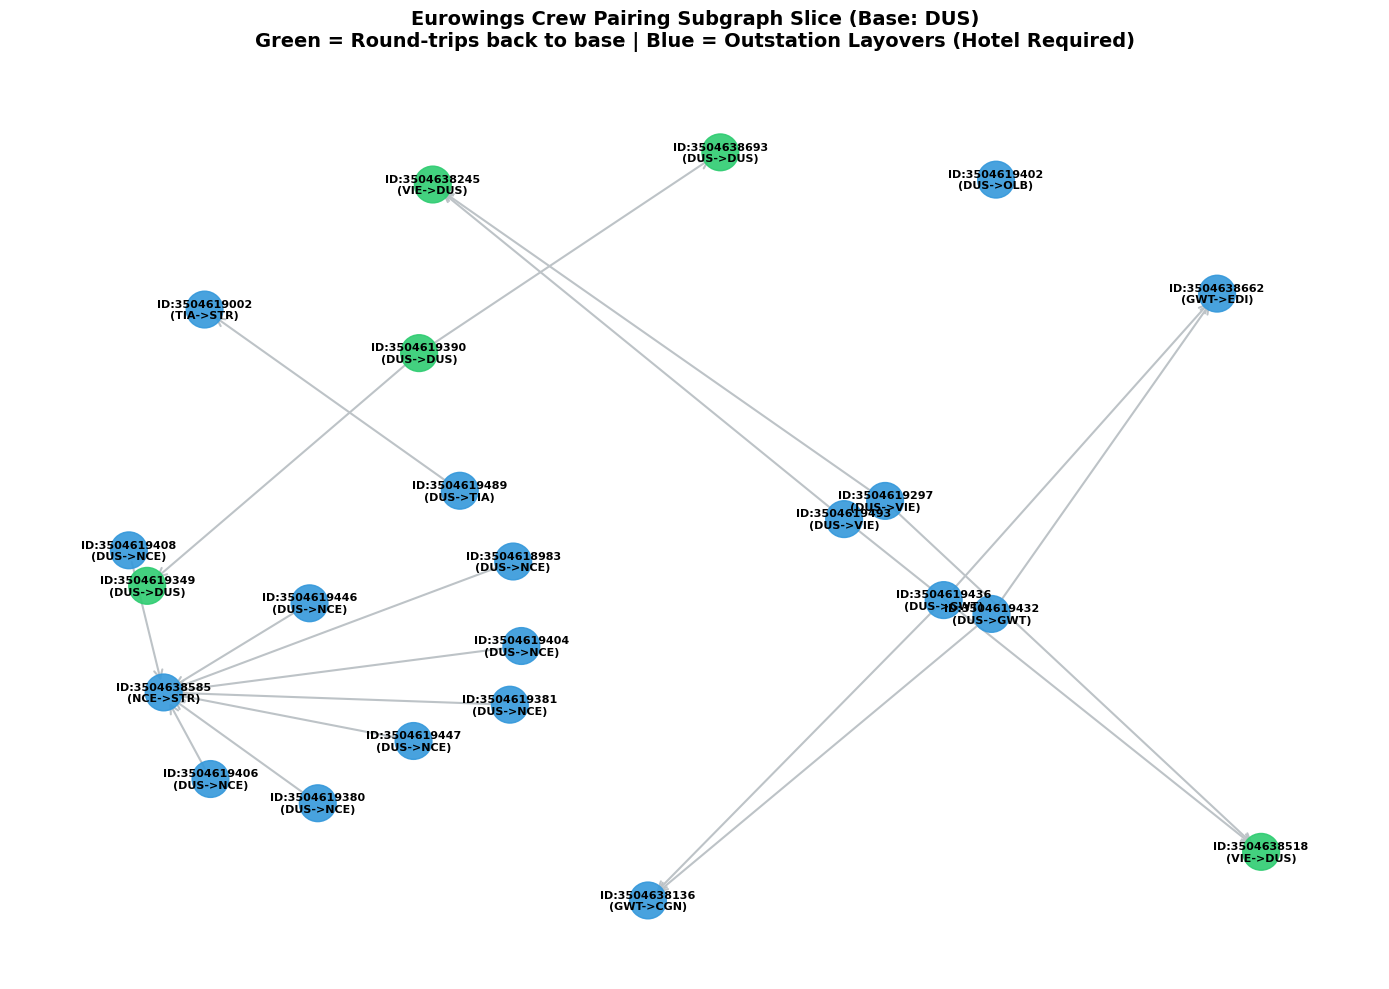

In [32]:
import matplotlib.pyplot as plt
def visualize_sample_subgraph(G, target_base='DUS', max_nodes_to_show=10):
    """
    Extracts and plots a visually clean slice of the pairing graph 
    originating from a specific home base.
    """
    # 1. Find nodes that start at our target base airport
    sample_nodes = [n for n, d in G.nodes(data=True) if d['origin'] == target_base][:max_nodes_to_show]
    
    # 2. Add some of their immediate legal connections (successors) to show transitions
    extended_nodes = list(sample_nodes)
    for n in sample_nodes:
        successors = list(G.successors(n))
        extended_nodes.extend(successors[:2]) # Grab up to 2 legal overnights per duty
        
    # Remove duplicates
    subgraph_nodes = list(set(extended_nodes))
    sub_G = G.subgraph(subgraph_nodes)
    
    # 3. Define the visual layout
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(sub_G, k=0.5, seed=42) # Spreads out the nodes nicely
    
    # 4. Color-code nodes by their destination to see where crews are flying to sleep
    node_colors = []
    for n in sub_G.nodes():
        dest = G.nodes[n]['destination']
        if dest == target_base:
            node_colors.append('#2ecc71') # Green for round-trips returning home
        else:
            node_colors.append('#3498db') # Blue for duties ending at an outstation layover
            
    # 5. Draw the network elements
    nx.draw_networkx_nodes(sub_G, pos, node_size=700, node_color=node_colors, alpha=0.9)
    nx.draw_networkx_edges(sub_G, pos, arrowstyle='->', arrowsize=15, edge_color='#bdc3c7', width=1.5)
    
    # Label nodes with their ID and Route string
    labels = {n: f"ID:{n}\n({G.nodes[n]['origin']}->{G.nodes[n]['destination']})" for n in sub_G.nodes()}
    nx.draw_networkx_labels(sub_G, pos, labels=labels, font_size=8, font_family='sans-serif', font_weight='bold')
    
    plt.title(f"Eurowings Crew Pairing Subgraph Slice (Base: {target_base})\n"
              f"Green = Round-trips back to base | Blue = Outstation Layovers (Hotel Required)", 
              fontsize=14, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Run the visualizer on your compiled graph!
visualize_sample_subgraph(weekly_G, target_base='DUS', max_nodes_to_show=15)

Crew Rostering Problem
For 7 Day Slice: 2025-04-27 - to - 2025-05-03
*Because our pairing output (final_optimal_pairings_matrix.csv) is strictly bounded by this 7-day slice, our downstream Rostering Engine will only be scheduling captains for this specific week. If we plan to roster for the entire month of May 2025, we will need to adjust the start_date and end_date variables in this pairing code to encompass the full month (e.g., 2025-05-01 to 2025-05-31) and re-run the notebook to generate a monthly pairing matrix first.*

In [33]:
import pandas as pd
import numpy as np
from datetime import datetime
import gurobipy as gp
from gurobipy import GRB
from collections import defaultdict
import ast
import os

print("=== STARTING MEMORY-OPTIMIZED ROSTERING LAYER ===")

# ==========================================
# 1. INDEPENDENT FILE INGESTION
# ==========================================
print("Loading datasets safely...")

# Load your new optimized pairings file
pairings_df = pd.read_csv(r"F:\Sushreeta MSc.DDS\2nd Sem\Analytics Project\3rd Round of Work\final_optimal_pairings_matrix.csv")

# Standardize the pairing ID column for the engine
if 'Pairing_ID' in pairings_df.columns:
    pairings_df['pairing_id'] = pairings_df['Pairing_ID']
else:
    pairings_df['pairing_id'] = pairings_df.index

# Set the index so Gurobi's .loc[p] lookups work flawlessly
pairings_df.set_index('pairing_id', drop=False, inplace=True)

# Load the remaining schedule and calendar datasets
flights_df = pd.read_csv(r"F:\Sushreeta MSc.DDS\2nd Sem\Analytics Project\3rd Round of Work\Copy_project_data\flight_schedule.csv")
home_bases_df = pd.read_csv(r"F:\Sushreeta MSc.DDS\2nd Sem\Analytics Project\3rd Round of Work\Copy_project_data\home_bases.csv")

# Load claims and requests, enforcing the semicolon delimiter
off_claims_df = pd.read_csv(r"F:\Sushreeta MSc.DDS\2nd Sem\Analytics Project\3rd Round of Work\Copy_project_data\off_claims_202505.csv", sep=";")
off_requests_df = pd.read_csv(r"F:\Sushreeta MSc.DDS\2nd Sem\Analytics Project\3rd Round of Work\Copy_project_data\off_requests_202505.csv", sep=";")

# CRITICAL FIX: Strip hidden trailing spaces from European CSV headers (e.g., 'Count ')
off_claims_df.columns = off_claims_df.columns.str.strip()
off_requests_df.columns = off_requests_df.columns.str.strip()

# ==========================================
# 2. DYNAMIC FEATURE ENGINEERING & RECONSTRUCTION
# ==========================================
print("Reconstructing missing features and timeline mappings...")

# 1. Safely parse the flight leg lists
# Your new file uses 'Flight_Leg_Sequence' instead of 'covered_legs'
if 'Flight_Leg_Sequence' in pairings_df.columns:
    pairings_df['covered_legs'] = pairings_df['Flight_Leg_Sequence'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )

# 2. Recover 'home_base' from the very first flight leg
leg_to_base_map = dict(zip(flights_df['LEG_ID'], flights_df['DEPARTURE_AIRPORT']))
pairings_df['home_base'] = pairings_df['covered_legs'].apply(
    lambda legs: leg_to_base_map.get(legs[0], 'DUS') if isinstance(legs, list) and len(legs) > 0 else 'DUS'
)

# 3. Calculate 'flying_hours' dynamically 
# Fallback calculation if block hours aren't explicitly provided
dep_time = pd.to_datetime(flights_df['SCHEDULED_DEPARTURE_TIME'])
arr_time = pd.to_datetime(flights_df['SCHEDULED_ARRIVAL_TIME'])
flights_df['calc_hours'] = (arr_time - dep_time).dt.total_seconds() / 3600.0
leg_hours_map = dict(zip(flights_df['LEG_ID'], flights_df['calc_hours']))

pairings_df['flying_hours'] = pairings_df['covered_legs'].apply(
    lambda legs: sum(leg_hours_map.get(leg, 0.0) for leg in legs) if isinstance(legs, list) else 0.0
)

# 4. Map the exact calendar execution days from flight legs
flights_df['REAL_DOM'] = pd.to_datetime(flights_df['SCHEDULED_DEPARTURE_TIME']).dt.day
leg_to_day_map = dict(zip(flights_df['LEG_ID'], flights_df['REAL_DOM']))

start_days = []
end_days = []
for idx, row in pairings_df.iterrows():
    legs = row['covered_legs']
    first_leg_day = leg_to_day_map.get(legs[0], 1) if isinstance(legs, list) and legs else 1
    last_leg_day = leg_to_day_map.get(legs[-1], first_leg_day) if isinstance(legs, list) and legs else 1
    
    start_days.append(first_leg_day)
    end_days.append(last_leg_day)

pairings_df['start_day'] = start_days
pairings_df['end_day'] = end_days

# 5. Calculate 'num_days' for fairness scaling
pairings_df['num_days'] = (pairings_df['end_day'] - pairings_df['start_day'] + 1).clip(lower=1)

# Ensure 'total_cost' exists (fallback to generic cost if omitted in the new format)
if 'total_cost' not in pairings_df.columns:
    pairings_df['total_cost'] = pairings_df['flying_hours'] * 100.0

print("✅ Features reconstructed successfully!")

=== STARTING MEMORY-OPTIMIZED ROSTERING LAYER ===
Loading datasets safely...
Reconstructing missing features and timeline mappings...
✅ Features reconstructed successfully!


In [34]:
# ==========================================
# 3. HIGH-SPEED HASH MAP INDEXING
# ==========================================
print("Building pre-indexed hash maps for timeline overlap tracking...")
pairings_by_day = defaultdict(list)
pairings_by_base = defaultdict(list)

for idx, row in pairings_df.iterrows():
    p_id = row['pairing_id']
    base = row['home_base']
    s_day = int(row['start_day'])
    e_day = int(row['end_day'])
    
    pairings_by_base[base].append(p_id)
    # Register pairing eligibility across its entire calendar span
    for d in range(s_day, e_day + 1):
        pairings_by_day[d].append(p_id)

# Parse pilot off-requests and hard leaves (KUR, U, SU)
hard_leave_codes = {'KUR', 'U', 'SU'}
captains_list = home_bases_df['captain_id'].unique().tolist()

active_days_range = sorted(list(pairings_by_day.keys()))
if not active_days_range:
    active_days_range = list(range(1, 32))

banned_captain_days = defaultdict(set)

def extract_day_int(date_str):
    try:
        return datetime.strptime(date_str.split()[0], "%d.%m.%y").day
    except:
        return 1

if 'Begin Date' in off_requests_df.columns:
    for _, row in off_requests_df.iterrows():
        c_id = row['captain_id']
        if c_id in captains_list:
            start_d = extract_day_int(row['Begin Date'])
            end_d = extract_day_int(row['End Date'])
            if str(row['Code']).strip() in hard_leave_codes:
                for d in range(start_d, end_d + 1):
                    banned_captain_days[c_id].add(d)

# ==========================================
# 4. MEMORY-OPTIMIZED GUROBI MODEL COMPILATION
# ==========================================
print("\nInitializing Gurobi Engine...")
model = gp.Model("Eurowings_Rostering_Fixed")

# Memory optimization parameters
model.setParam('Method', 2)       # Force Barrier Method to limit peak memory usage
model.setParam('NodefileStart', 0.5) # Offload to disk if RAM exceeds 500MB

# CRITICAL RAM TRICK: Prune combinations before creating decision variables
valid_y_pairs = []
for _, cap_row in home_bases_df.iterrows():
    c = cap_row['captain_id']
    c_base = cap_row['home_base']
    for p in pairings_by_base[c_base]:
        valid_y_pairs.append((c, p))

print(f"Instantiating {len(valid_y_pairs)} base-compliant decision variables...")
y = model.addVars(valid_y_pairs, vtype=GRB.BINARY, name="y")
dev = model.addVars(captains_list, vtype=GRB.CONTINUOUS, lb=0.0, name="dev")

# MUST instantiate slack variables BEFORE objective definition
print("Instantiating uncovered pairing slack variables...")
uncovered = model.addVars(pairings_df['pairing_id'], vtype=GRB.BINARY, name="uncovered")

# --- Objective Definition ---
penalty_fairness_weight = 500.0
PENALTY_UNCOVERED = 100000.0  # Heavy penalty for unassigned pairings

operational_cost_expr = gp.quicksum(y[c, p] * pairings_df.loc[p, 'total_cost'] for (c, p) in valid_y_pairs)
fairness_imbalance_expr = gp.quicksum(dev[c] * penalty_fairness_weight for c in captains_list)
uncovered_penalty_expr = gp.quicksum(uncovered[p] * PENALTY_UNCOVERED for p in pairings_df['pairing_id'])

# Unified Objective
model.setObjective(operational_cost_expr + fairness_imbalance_expr + uncovered_penalty_expr, GRB.MINIMIZE)
print("✅ Multi-objective function successfully compiled with slack penalties!")

# ==========================================
# 5. CONSTRAINT FORMULATIONS
# ==========================================
# Constraint 1: Set Partitioning Coverage with Slack Variable
print("Formulating flexible pairing coverage matrices...")
for p in pairings_df['pairing_id']:
    p_base = pairings_df.loc[p, 'home_base']
    valid_caps_for_p = home_bases_df[home_bases_df['home_base'] == p_base]['captain_id'].tolist()
    
    model.addConstr(
        gp.quicksum(y[c, p] for c in valid_caps_for_p if (c, p) in y) + uncovered[p] == 1, 
        name=f"Cover_P_{p}"
    )

# Constraint 2: Timeline Overlap & Leave Blocking
print("Formulating calendar pacing constraints...")
for c in captains_list:
    c_base = home_bases_df[home_bases_df['captain_id'] == c]['home_base'].values[0]
    base_pairings = set(pairings_by_base[c_base])
    
    for d in active_days_range:
        pairings_on_day = [p for p in pairings_by_day[d] if p in base_pairings]
        
        if not pairings_on_day:
            continue
            
        if d in banned_captain_days[c]:
            for p in pairings_on_day:
                model.addConstr(y[c, p] == 0, name=f"Leave_Block_{c}_{d}_{p}")
        else:
            model.addConstr(gp.quicksum(y[c, p] for p in pairings_on_day) <= 1, name=f"No_Overlap_{c}_{d}")

# Constraint 3: EASA Cumulative Flight Hours Limit
print("Formulating EASA fatigue limit bounds...")
for c in captains_list:
    c_base = home_bases_df[home_bases_df['captain_id'] == c]['home_base'].values[0]
    caps_pairings = pairings_by_base[c_base]
    model.addConstr(
        gp.quicksum(y[c, p] * pairings_df.loc[p, 'flying_hours'] for p in caps_pairings) <= 60.0,
        name=f"EASA_Cap_{c}"
    )

# Constraint 4: Schedule Fairness
print("Formulating absolute deviation fairness bounds...")
for c in captains_list:
    matching_claim = off_claims_df[off_claims_df['captain_id'] == c]
    # Because of the .str.strip() fix above, 'Count' is now safe to use!
    target_monthly_claim = matching_claim['Count'].values[0] if not matching_claim.empty else 10
    
    horizon_days_count = len(active_days_range) if len(active_days_range) > 0 else 30
    scaled_target_claim = (target_monthly_claim / 31.0) * horizon_days_count
    
    c_base = home_bases_df[home_bases_df['captain_id'] == c]['home_base'].values[0]
    caps_pairings = pairings_by_base[c_base]
    
    total_days_worked = gp.quicksum(y[c, p] * pairings_df.loc[p, 'num_days'] for p in caps_pairings)
    observed_days_off = horizon_days_count - total_days_worked
    
    model.addConstr(dev[c] >= scaled_target_claim - observed_days_off, name=f"Fairness_SideA_{c}")
    model.addConstr(dev[c] >= observed_days_off - scaled_target_claim, name=f"Fairness_SideB_{c}")

# ==========================================
# 6. EXECUTION & OUTPUT PARSING
# ==========================================
print("\n>>> Launching Gurobi Engine Optimizer Matrix...")
model.optimize()

# Diagnostic and Extraction
if model.status == 3:  # GRB.INFEASIBLE
    print("❌ Model is Infeasible. Isolating the conflict via IIS...")
    model.computeIIS()
    model.write("model_conflict.ilp")
    print("✅ Conflict report written to 'model_conflict.ilp'. Open this file to see which rules clashed.")
elif model.status == 2:  # GRB.OPTIMAL
    print(f"\nOptimization Successful! Global Network Roster Cost: €{model.objVal:,.2f}")
    
    uncovered_count = 0
    for p in pairings_df['pairing_id']:
        if uncovered[p].X > 0.5:
            uncovered_count += 1
    print(f"Total pairings dropped to contract slack reserves (Uncovered): {uncovered_count}")

    roster_output = []
    for (c, p) in valid_y_pairs:
        if y[c, p].X > 0.5:
            p_info = pairings_df.loc[p]
            roster_output.append({
                'Captain_ID': c,
                'Home_Base': home_bases_df[home_bases_df['captain_id'] == c]['home_base'].values[0],
                'Assigned_Pairing_ID': p,
                'Start_Day': p_info['start_day'],
                'End_Day': p_info['end_day'],
                'Flying_Hours': round(p_info['flying_hours'], 2),
                'Route_Cost': round(p_info['total_cost'], 2)
            })
            
    roster_output_df = pd.DataFrame(roster_output)
    roster_output_df.to_csv("final_named_captain_roster.csv", index=False)
    
    print("\n=== ROSTER GENERATION COMPLETE! RESULTS SAVED TO 'final_named_captain_roster.csv' ===")
    
    from IPython.display import display
    display(roster_output_df.head(15))
else:
    print(f"Solver terminated with non-optimal code. Status: {model.status}")

Building pre-indexed hash maps for timeline overlap tracking...

Initializing Gurobi Engine...
Set parameter Method to value 2
Set parameter NodefileStart to value 0.5
Instantiating 140444 base-compliant decision variables...
Instantiating uncovered pairing slack variables...
✅ Multi-objective function successfully compiled with slack penalties!
Formulating flexible pairing coverage matrices...
Formulating calendar pacing constraints...
Formulating EASA fatigue limit bounds...
Formulating absolute deviation fairness bounds...

>>> Launching Gurobi Engine Optimizer Matrix...
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i3-7100U CPU @ 2.40GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 2 physical cores, 4 logical processors, using up to 4 threads

Non-default parameters:
Method  2
NodefileStart  0.5

Optimize a model with 20651 rows, 142731 columns and 708995 nonzeros (Min)
Model fingerprint: 0x811b117b
Model has 14273

,Captain_ID,Home_Base,Assigned_Pairing_ID,Start_Day,End_Day,Flying_Hours,Route_Cost
0,640,DUS,ORGANIC_DUTY_BASE_TRIP_4156,27,28,6.92,691.67
1,790,HAM,EMERGENCY_STUB_3504619274,27,27,3.50,350.00
2,790,HAM,ORGANIC_DUTY_BASE_TRIP_12296,29,29,2.50,250.00
3,790,HAM,ORGANIC_DUTY_BASE_TRIP_18924,30,30,2.50,250.00
4,790,HAM,ORGANIC_DUTY_BASE_TRIP_25986,1,1,6.92,691.67
5,708,DUS,EMERGENCY_STUB_3504658157,29,29,1.58,158.33
6,708,DUS,ORGANIC_DUTY_BASE_TRIP_31381,2,2,5.83,583.33
7,708,DUS,ORGANIC_DUTY_BASE_TRIP_38233,3,3,6.67,666.67
8,708,DUS,ORGANIC_DUTY_BASE_TRIP_5290,28,28,10.00,1000.00
9,636,NUE,ORGANIC_DUTY_BASE_TRIP_12054,29,29,4.50,450.00


In [35]:
print(f"Total assignments generated: {len(roster_output_df)}")

Total assignments generated: 1365


In [36]:
# Check how many pairings ended up using the 'uncovered' slack variable
uncovered_pairings = [p for p in pairings_df['pairing_id'] if uncovered[p].X > 0.5]

print("=== COVREAGE GAP DIAGNOSTIC ===")
print(f"Total pairings left uncovered: {len(uncovered_pairings)}")
if uncovered_pairings:
    print(f"Unassigned Pairing IDs: {uncovered_pairings}")
    # Show data details for those missing pairings to figure out why they failed
    display(pairings_df[pairings_df['pairing_id'].isin(uncovered_pairings)])
else:
    print("🎉 Perfection! 100% of flight pairings were fully covered by your captains.")

=== COVREAGE GAP DIAGNOSTIC ===
Total pairings left uncovered: 490
Unassigned Pairing IDs: ['EMERGENCY_STUB_3504618802', 'EMERGENCY_STUB_3504618856', 'EMERGENCY_STUB_3504618860', 'EMERGENCY_STUB_3504618869', 'EMERGENCY_STUB_3504618880', 'EMERGENCY_STUB_3504618888', 'EMERGENCY_STUB_3504618897', 'EMERGENCY_STUB_3504618917', 'EMERGENCY_STUB_3504618919', 'EMERGENCY_STUB_3504618949', 'EMERGENCY_STUB_3504618951', 'EMERGENCY_STUB_3504618981', 'EMERGENCY_STUB_3504618990', 'EMERGENCY_STUB_3504618994', 'EMERGENCY_STUB_3504619000', 'EMERGENCY_STUB_3504619002', 'EMERGENCY_STUB_3504619004', 'EMERGENCY_STUB_3504619009', 'EMERGENCY_STUB_3504619025', 'EMERGENCY_STUB_3504619105', 'EMERGENCY_STUB_3504619122', 'EMERGENCY_STUB_3504619148', 'EMERGENCY_STUB_3504619150', 'EMERGENCY_STUB_3504619214', 'EMERGENCY_STUB_3504619217', 'EMERGENCY_STUB_3504619303', 'EMERGENCY_STUB_3504619319', 'EMERGENCY_STUB_3504619328', 'EMERGENCY_STUB_3504619330', 'EMERGENCY_STUB_3504619342', 'EMERGENCY_STUB_3504619346', 'EMERGENC

,Pairing_ID,Deployment_Type,Total_Operating_Sectors,Flight_Leg_Sequence,Itinerary_Chain,Passive_Deadheads_Assigned,pairing_id,covered_legs,home_base,flying_hours,start_day,end_day,num_days,total_cost
pairing_id,,,,,,,,,,,,,,
EMERGENCY_STUB_3504618802,EMERGENCY_STUB_3504618802,Emergency Fallback Stub,1,[3504618802],TUN➔CGN,0,EMERGENCY_STUB_3504618802,[3504618802],TUN,2.500000,27,27,1,250.000000
EMERGENCY_STUB_3504618856,EMERGENCY_STUB_3504618856,Emergency Fallback Stub,1,[3504618856],BUD➔CGN,0,EMERGENCY_STUB_3504618856,[3504618856],BUD,1.833333,27,27,1,183.333333
EMERGENCY_STUB_3504618860,EMERGENCY_STUB_3504618860,Emergency Fallback Stub,1,[3504618860],VCE➔CGN,0,EMERGENCY_STUB_3504618860,[3504618860],VCE,1.583333,27,27,1,158.333333
EMERGENCY_STUB_3504618869,EMERGENCY_STUB_3504618869,Emergency Fallback Stub,1,[3504618869],VRN➔CGN,0,EMERGENCY_STUB_3504618869,[3504618869],VRN,1.500000,27,27,1,150.000000
EMERGENCY_STUB_3504618880,EMERGENCY_STUB_3504618880,Emergency Fallback Stub,1,[3504618880],ALC➔CGN,0,EMERGENCY_STUB_3504618880,[3504618880],ALC,2.666667,27,27,1,266.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ORGANIC_DUTY_BASE_TRIP_785,ORGANIC_DUTY_BASE_TRIP_785,Organic Mainline,2,"[3504618967, 3504618920]",PMI➔STR ➔ STR➔BER,1,ORGANIC_DUTY_BASE_TRIP_785,"[3504618967, 3504618920]",PMI,3.250000,27,27,1,325.000000
ORGANIC_DUTY_BASE_TRIP_8152,ORGANIC_DUTY_BASE_TRIP_8152,Organic Mainline,3,"[3504638134, 3504638091, 3504638174]",LIS➔CGN ➔ CGN➔BER ➔ BER➔STR,1,ORGANIC_DUTY_BASE_TRIP_8152,"[3504638134, 3504638091, 3504638174]",LIS,5.166667,28,28,1,516.666667
ORGANIC_DUTY_BASE_TRIP_8223,ORGANIC_DUTY_BASE_TRIP_8223,Organic Mainline,2,"[3504638124, 3504638097]",PMI➔CGN ➔ MUC➔CGN,1,ORGANIC_DUTY_BASE_TRIP_8223,"[3504638124, 3504638097]",PMI,3.500000,28,28,1,350.000000


In [37]:
import numpy as np

deviations = [dev[c].X for c in captains_list]
print("=== ROSTER FAIRNESS / IMBALANCE METRICS ===")
print(f"Max Imbalance Observed: {max(deviations):.2f} days")
print(f"Min Imbalance Observed: {min(deviations):.2f} days")
print(f"Average Workload Deviation: {np.mean(deviations):.2f} days")

=== ROSTER FAIRNESS / IMBALANCE METRICS ===
Max Imbalance Observed: 5.65 days
Min Imbalance Observed: 0.03 days
Average Workload Deviation: 1.41 days


In [39]:
valid_captain_bases = home_bases_df['home_base'].unique().tolist()
print(f"Bases with available captains: {valid_captain_bases}")

# Count how many pairings start at bases not in that list
doomed_pairings = pairings_df[~pairings_df['home_base'].isin(valid_captain_bases)]
print(f"\nTotal pairings starting at unstaffed outstations: {len(doomed_pairings)}")


Bases with available captains: ['DUS', 'HAM', 'NUE', 'CGN', 'STR', 'BER', 'HAJ', 'MUC']

Total pairings starting at unstaffed outstations: 440
